# Introdución

El tercer proyecto de investigación prpuesto por Alura Latam. Continuando del proyecto anterior donde se realizó un análisis descriptivo, ahora nos enfocaremos en diversos algoritmos predictivos. Nos encontramos con la empresa Telecom X que se enfrenta a un problema de alta tasa cancelación. Nuestro objetivo es poder crear un algoritmo predictivo para identificar que clientes dejarán la empresa.


## ADVERTENCIA

 Se asume que los datos pertenecen al mismo periodo de tiempo (mismo mes). Si los datos fueron extraidos durante periodos extendidos en el tiempo, entonces el tipo de análisis debería modificarse (a un análisis de supervivencia).

## Diccionario de variables

- customer_id: número de identificación único de cada cliente
- churn: cliente dejó la empresa (1:Sí, 0:No)
- gender_male: género (1:masculino, 0:femenino)
- senior_citizen_65: cliente mayor a 64 años (1:Sí, 0:No)
- partner: cliente tiene una pareja (1:Sí, 0:No)
- dependents: cliente tiene dependientes (1:Sí, 0:No)
- tenure: meses de contrato del cliente
- phone_service: cliente suscrito al servicio telefónico (1:Sí, 0:No)
- multiple_lines: cliente suscrito a más de una línea telefónica (1:Sí, 0:No)
- internet_service: cliente suscrito a un proveedor de internet (1:Sí, 0:No)
- online_security: cliente suscrito al seguridad en línea (1:Sí, 0:No)
- online_backup: cliente suscrito a respaldo en línea (1:Sí, 0:No)
- device_protection: cliente suscrito a protección del dispositivo (1:Sí, 0:No)
- tech_support: cliente suscrito a soporte técnico (1:Sí, 0:No)
- streaming_tv: cliente suscrito a televisión por cable (1:Sí, 0:No)
- streaming_movies: cliente suscrito a streaming de películas (1:Sí, 0:No)
- contract: tipo de contrato (month_to_month, one_year, two_year)
- paperless_billing: cliente prefiere recibir la factura en línea (1:Sí, 0:No)
- payment_method: forma de pago
- charges_monthly: total de todos los servicios del cliente por mes
- charges_total: total gastado por el cliente
- family: El cliente tiene pareja o dependientes. (1:sí, 0:no)
- tenure_log: logaritmo de la antigüedad del cliente.
- dsl: toma el valor 1 si el servicio de internet es por DSL, 0 en otro caso.
- fiber_optic: toma el valor 1 si el servicio de internet es por fibra optica, 0 en otro caso.
- no_internet: toma el valor 1 si no hay servicio de internet.
- subcription_total: Cuenta la cantidad de servicios a lo que el usuario esta subscrito.
- subcription_no_streaming: Cuenta la cantidad de servicios a lo que el usuario esta subscrito, ignorando los de streaming
- streaming: cliente suscrito a streaming_tv o streaming_movies (1:sí, 0:no)
- month_to_month: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.
- one_year: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.
- two_year: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.
- charges_average : Se suman los gaston mensuales y totales (los gastos acumulados más los gastos de este mes) y se dividen por tenure + 1 (contando el mes).
- charges_average_log : logaritmo de los gastos promedios.
- charges_total_log : logaritmo de los gastos totales.
- electronic_check: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- mailed_check: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- bank_transfer_automatic: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- credit_card_automatic: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- automatic_payment: : toma el valor 1 si el método de pago es credit_card_automatic o bank_transfer_automatic, 0 en otro caso.

#Preparación

## Importa librerías

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random



from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)



### Versiones:


- pandas: 2.2.2
- numpy: 2.0.2
- matplotlib: 3.10.0
- seaborn: 0.13.2
- joblib: 1.5.3
- statsmodels: 0.14.6
- scikit-learn: 1.6.1


In [8]:
# No es necesario volver a correr
'''
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import joblib
import random
import sklearn
import statsmodels




print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"joblib: {joblib.__version__}")
print(f"statsmodels: {statsmodels.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
'''

'\nimport pandas as pd\nimport numpy as np\nimport matplotlib\nimport seaborn as sns\nimport joblib\nimport random\nimport sklearn\nimport statsmodels\n\n\n\n\nprint(f"pandas: {pd.__version__}")\nprint(f"numpy: {np.__version__}")\nprint(f"matplotlib: {matplotlib.__version__}")\nprint(f"seaborn: {sns.__version__}")\nprint(f"joblib: {joblib.__version__}")\nprint(f"statsmodels: {statsmodels.__version__}")\nprint(f"scikit-learn: {sklearn.__version__}")\n'

## Importa base de datos

In [9]:

url =  "https://github.com/TheNaranjero/Challenge-2-Data-Science/raw/refs/heads/main/data_limpio.csv"

df = pd.read_csv(url)

df.head()

,customer_id,churn,gender_male,senior_citizen_65,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,month_to_month,one_year,two_year,bank_transfer_automatic,credit_card_automatic,electronic_check,mailed_check,automatic_payment,subcription_total_group,subcription_no_streaming_group
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,0,0,0,0,1,0,3-4,2
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,1,0,0,0,0,0,1,0,0-2,0-1
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,0,1,0,0,0-2,0-1
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,0,0,0,1,0,0,3-4,2
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,1,0,0,0,0,0,1,0,0-2,0-1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     7032 non-null   object 
 1   churn                           7032 non-null   int64  
 2   gender_male                     7032 non-null   int64  
 3   senior_citizen_65               7032 non-null   int64  
 4   partner                         7032 non-null   int64  
 5   dependents                      7032 non-null   int64  
 6   tenure                          7032 non-null   int64  
 7   phone_service                   7032 non-null   int64  
 8   multiple_lines                  7032 non-null   int64  
 9   internet_service                7032 non-null   object 
 10  online_security                 7032 non-null   int64  
 11  online_backup                   7032 non-null   int64  
 12  device_protection               70

## Funciones

### Loess

In [11]:


def LoessPlot(var):
  # Assume your dataframe is df
  x = df[var]
  y = df["churn"]

  # Fit LOESS
  loess_fit = lowess(
      y,
      x,
      frac=0.3,      # smoothing parameter
      it=0           # no robust iterations (good for binary data)
      )
  # Extract fitted values
  x_loess = loess_fit[:,0]
  y_loess = loess_fit[:,1]

  # Plot
  plt.scatter(x, y, alpha=0.2)
  plt.plot(x_loess, y_loess)
  plt.xlabel(var)
  plt.ylabel("Churn probability")
  plt.show()

## Eliminación de Columnas Irrelevantes

Se eliminan columnas repetidas o que no aportan información:
- customer_id:  es una variable id
- internet_service: fue recategorizada en dsl, fiber_optic y no_internet
- contract: fue recategorizada en month_to_month, one_year y two_year
- payment_method: fue recategorizada en bank_transfer_automatic,     credit_card_automatic, electronic_check y mailed_check.
- subcription_total_group y subcription_no_streaming_group: se trata de versiones categoricas de subcription_total y subcription_no_streaming por lo que se descartan.
- charges_average: por ser equivalente a charges_monthly
- charges_average_log: por ser equivalente a charges_monthly_log
- charges_daily: por contener la misma información que charges_monthly.
- charges_total: por ser la multiplicación charges_monthly x tenure.
- charges_total_log: idem anterior.
- charges_monthly: fue transformada a logaritmo, presentando menos valores extremos y mayor simetría.
- tenure: fue transformada a logaritmo, presentando menos valores extremos y mayor simetría.

In [12]:
vars = ['churn', 'gender_male', 'senior_citizen_65', 'partner',
       'dependents', 'phone_service', 'multiple_lines',
        'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
         'paperless_billing',
       'charges_monthly_log',  'tenure_log',
        'subcription_no_streaming', 'subcription_total',
       'streaming', 'family', 'dsl', 'fiber_optic', 'no_internet',
       'month_to_month', 'one_year', 'two_year', 'bank_transfer_automatic',
       'credit_card_automatic', 'electronic_check', 'mailed_check',
    ]

df = df[vars]
df.head()

,churn,gender_male,senior_citizen_65,partner,dependents,phone_service,multiple_lines,online_security,online_backup,device_protection,...,dsl,fiber_optic,no_internet,month_to_month,one_year,two_year,bank_transfer_automatic,credit_card_automatic,electronic_check,mailed_check
0,0,0,0,1,1,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
1,0,1,0,0,0,1,1,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,1,1,0,0,0,1,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3,1,1,1,1,0,1,0,0,1,1,...,0,1,0,1,0,0,0,0,1,0
4,1,0,1,1,0,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1


# Análisis Exploratorio

## Proporción de Churn

- Se analiza que proporción de los datos que son evasores.
- Encontramos un 73% de no evasores y un 27% de evasores.
- Se concidera que la diferencia no es tan grande como para utilizar under o oversampling. Pero se requerirá de un ajuste en la regla de decisión para compensar esto.


In [13]:
df["churn"].value_counts(normalize=True).round(3) * 100

,proportion
churn,
0,73.4
1,26.6


## Análisis de correlación

Las que más se correlacionaron con churn fueron:
- month_to_month (0.40)
- tenure_log (-0.38)
- electronic_check (0.30)
- two_year(-0.30)

In [14]:
df.corr(numeric_only=True).round(2)

,churn,gender_male,senior_citizen_65,partner,dependents,phone_service,multiple_lines,online_security,online_backup,device_protection,...,dsl,fiber_optic,no_internet,month_to_month,one_year,two_year,bank_transfer_automatic,credit_card_automatic,electronic_check,mailed_check
churn,1.00,-0.01,0.15,-0.15,-0.16,0.01,0.04,-0.17,-0.08,-0.07,...,-0.12,0.31,-0.23,0.40,-0.18,-0.30,-0.12,-0.13,0.30,-0.09
gender_male,-0.01,1.00,-0.00,-0.00,0.01,-0.01,-0.01,-0.02,-0.01,-0.00,...,0.01,-0.01,0.00,-0.00,0.01,-0.00,-0.02,0.00,0.00,0.01
senior_citizen_65,0.15,-0.00,1.00,0.02,-0.21,0.01,0.14,-0.04,0.07,0.06,...,-0.11,0.25,-0.18,0.14,-0.05,-0.12,-0.02,-0.02,0.17,-0.15
partner,-0.15,-0.00,0.02,1.00,0.45,0.02,0.14,0.14,0.14,0.15,...,-0.00,0.00,-0.00,-0.28,0.08,0.25,0.11,0.08,-0.08,-0.10
dependents,-0.16,0.01,-0.21,0.45,1.00,-0.00,-0.02,0.08,0.02,0.01,...,0.05,-0.16,0.14,-0.23,0.07,0.20,0.05,0.06,-0.15,0.06
phone_service,0.01,-0.01,0.01,0.02,-0.00,1.00,0.28,-0.09,-0.05,-0.07,...,-0.45,0.29,0.17,-0.00,-0.00,0.00,0.01,-0.01,0.00,-0.00
multiple_lines,0.04,-0.01,0.14,0.14,-0.02,0.28,1.00,0.10,0.20,0.20,...,-0.20,0.37,-0.21,-0.09,-0.00,0.11,0.08,0.06,0.08,-0.23
online_security,-0.17,-0.02,-0.04,0.14,0.08,-0.09,0.10,1.00,0.28,0.27,...,0.32,-0.03,-0.33,-0.25,0.10,0.19,0.09,0.12,-0.11,-0.08
online_backup,-0.08,-0.01,0.07,0.14,0.02,-0.05,0.20,0.28,1.00,0.30,...,0.16,0.17,-0.38,-0.16,0.08,0.11,0.09,0.09,-0.00,-0.17
device_protection,-0.07,-0.00,0.06,0.15,0.01,-0.07,0.20,0.27,0.30,1.00,...,0.15,0.18,-0.38,-0.23,0.10,0.17,0.08,0.11,-0.00,-0.19


### Mapa de calor e importancia de variables
Aparecen varios grupos de variables altamente correlacionados. Estos pueden resultar un problema para modelos paramétricos (regresión logística, probit o cloglog), aunque no  deberían afectar a la mayoría de los algoritmos aquí utilizados.
Las correlaciones más altas fueron:
- Partner y Family
-  Streaming, streaming movies y streaming tv
- No internet y charges monthly log
- substcription total no streaming

Este análisis se complementa con un ranking de importancia de variables. Donde observamos que las variables más importantes con mucha diferencia son tenuere log y charge_monthly_log.

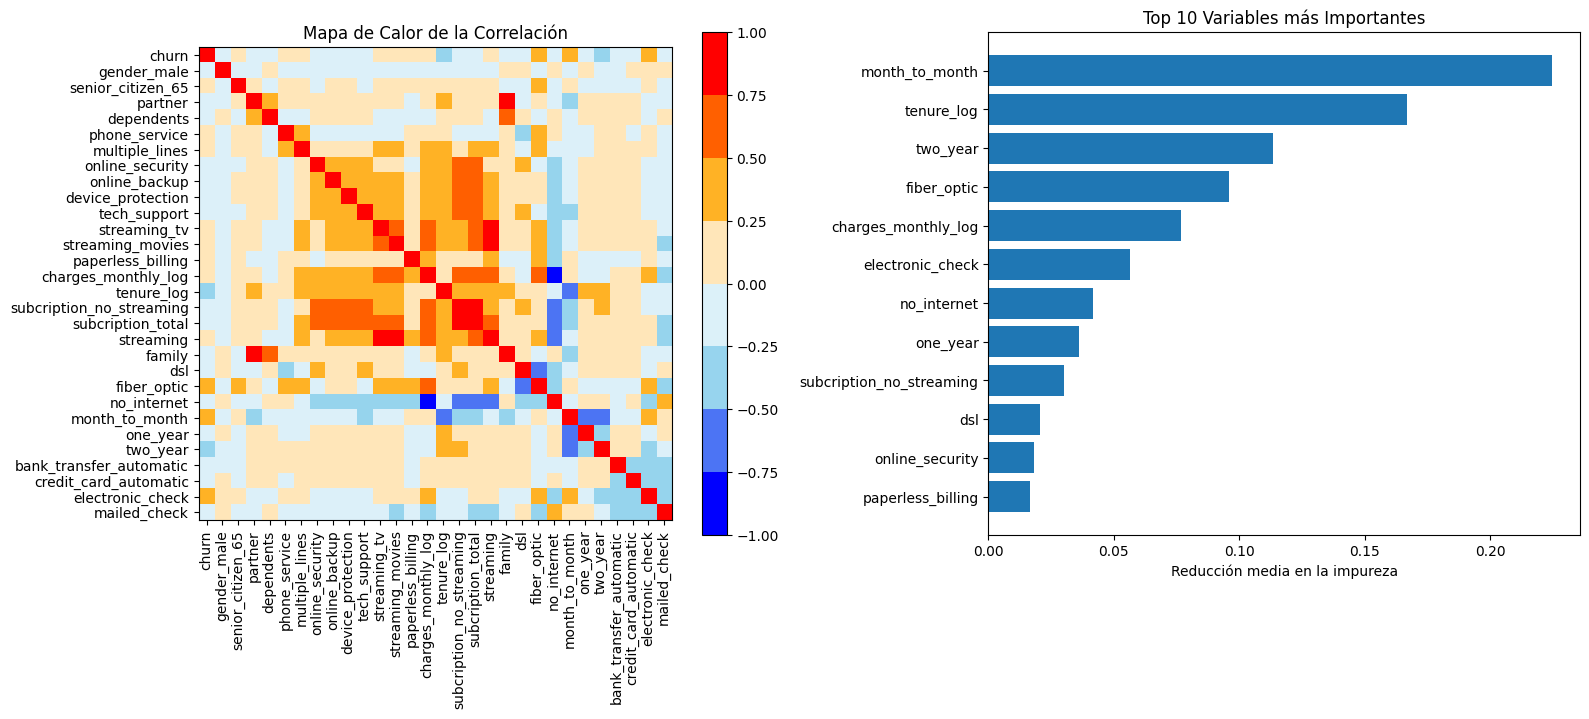

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier

# ---- Correlation matrix ----
corr = df.corr(numeric_only=True)

bounds = np.arange(-1, 1.1, 0.25)
norm = BoundaryNorm(bounds, 256)

colors = ["blue", "skyblue", "white", "orange", "red"]
cmap = LinearSegmentedColormap.from_list("custom", colors)

# ---- Random Forest ----
rf = RandomForestClassifier(
    min_samples_split = 50,
    max_depth = 7,
    class_weight="balanced",
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(df.drop(columns="churn"), df["churn"])

importance = pd.Series(
    rf.feature_importances_,
    index=df.drop(columns="churn").columns
)

importance = importance.sort_values(ascending=False)

topN = 12
importance_top = importance.head(topN)

# ---- Figure 1x2 ----
fig, axes = plt.subplots(1, 2, figsize=(16,7))

# ---- Heatmap ----
im = axes[0].imshow(corr, cmap=cmap, norm=norm)

axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_xticklabels(corr.columns, rotation=90)

axes[0].set_yticks(range(len(corr.columns)))
axes[0].set_yticklabels(corr.columns)

axes[0].set_title("Mapa de Calor de la Correlación")

fig.colorbar(im, ax=axes[0], ticks=bounds)


# ---- Importance Barplot ----
axes[1].barh(
    importance_top.index[::-1],
    importance_top.values[::-1]
)

axes[1].set_title("Top 10 Variables más Importantes")
axes[1].set_xlabel("Reducción media en la impureza")

plt.tight_layout()
plt.show()

In [16]:
df = df.drop(columns=["family", "streaming", "no_internet", "subcription_total"])

## Variables cualitativas

In [17]:
import numpy as np

target = "churn"   # name of your target variable

# Select dummy variables (excluding the target)
cat_vars = [ 'gender_male', 'senior_citizen_65', 'partner',
       'dependents', 'phone_service', 'multiple_lines',
        'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
         'paperless_billing',
        'dsl', 'fiber_optic',

       'month_to_month', 'one_year', 'two_year', 'bank_transfer_automatic',
       'credit_card_automatic', 'electronic_check', 'mailed_check']

## Compute percentages
table = (df.groupby(target)[cat_vars].mean().T * 100).round(0)

# Rename columns
table.columns = ["Target = 0", "Target = 1"]

# Add difference column
table["Difference"] =np.abs( table["Target = 1"] - table["Target = 0"] )

# Add variable names as a column
table.insert(0, "Variable", table.index)

# Round values
table[["Target = 0","Target = 1","Difference"]] = \
    table[["Target = 0","Target = 1","Difference"]].round(1)

table = table.sort_values("Difference", ascending=False)
table2 = table.copy()
for col in ["Target = 0","Target = 1","Difference"]:
    table2[col] = table2[col].map(lambda x: f"{int(x)}%")

table2

,Variable,Target = 0,Target = 1,Difference
month_to_month,month_to_month,43%,89%,46%
fiber_optic,fiber_optic,35%,69%,34%
electronic_check,electronic_check,25%,57%,32%
two_year,two_year,32%,3%,29%
paperless_billing,paperless_billing,54%,75%,21%
dependents,dependents,34%,17%,17%
partner,partner,53%,36%,17%
online_security,online_security,33%,16%,17%
tech_support,tech_support,34%,17%,17%
one_year,one_year,25%,9%,16%


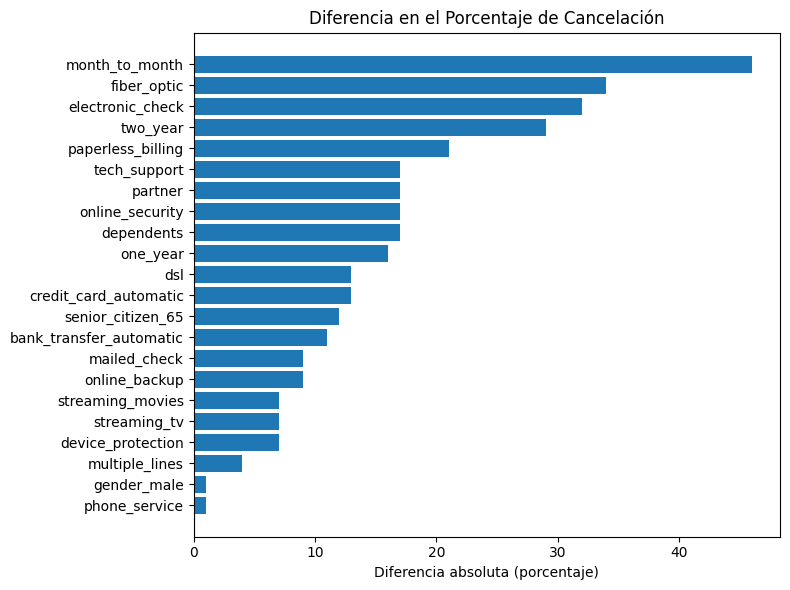

In [18]:
diff = table["Difference"].sort_values()

plt.figure(figsize=(8,6))

plt.barh(
    diff.index,
    diff.values
)

plt.axvline(0)

plt.xlabel("Diferencia absoluta (porcentaje)")
plt.title("Diferencia en el Porcentaje de Cancelación")

plt.tight_layout()
plt.show()

## Variables Numéricas

In [19]:

target = "churn"   # change to your target variable

# Select numerical variables (excluding target)
num_vars = [  'charges_monthly_log',  'tenure_log',
        'subcription_no_streaming'  ]

results = []

for var in num_vars:

    group0 = df[df[target] == 0][var].dropna()
    group1 = df[df[target] == 1][var].dropna()

    mean0 = group0.mean()
    mean1 = group1.mean()

    sd0 = group0.std()
    sd1 = group1.std()

    n0 = len(group0)
    n1 = len(group1)

    # Pooled SD
    pooled_sd = np.sqrt(
        ((n0 - 1)*sd0**2 + (n1 - 1)*sd1**2) / (n0 + n1 - 2)
    )

    # Cohen's d
    cohen_d = np.abs(mean1 - mean0) / pooled_sd if pooled_sd > 0 else np.nan

    results.append([
        var,
        f"{mean0:.1f} ({sd0:.1f})",
        f"{mean1:.1f} ({sd1:.1f})",
        cohen_d
    ])

# Build table
table_num = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "Target = 0 Mean (SD)",
        "Target = 1 Mean (SD)",
        "Cohen d"
    ]
)

# Sort by effect size
table_num = table_num.sort_values("Cohen d", ascending=False)

# Round Cohen d
table_num["Cohen d"] = table_num["Cohen d"].round(2)

table_num

,Variable,Target = 0 Mean (SD),Target = 1 Mean (SD),Cohen d
1,tenure_log,3.2 (1.1),2.1 (1.4),0.92
0,charges_monthly_log,3.9 (0.6),4.2 (0.4),0.49
2,subcription_no_streaming,1.4 (1.4),0.9 (1.0),0.40


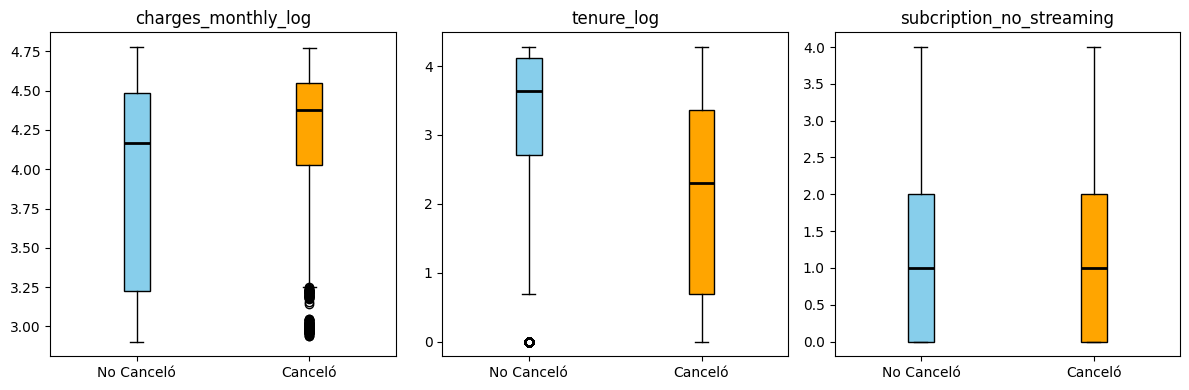

In [20]:
import matplotlib.pyplot as plt
import numpy as np

target = "churn"

# Select numerical variables (excluding target)
num_vars = [  'charges_monthly_log',  'tenure_log',
        'subcription_no_streaming',  ]

# Choose how many variables to plot
vars_to_plot = num_vars[:4]   # first 4 variables

# Grid size
rows = 1
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(12,4))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):

    group0 = df[df[target]==0][var]
    group1 = df[df[target]==1][var]

    bp = axes[i].boxplot([group0, group1] ,
        medianprops=dict(color="black", linewidth=2),
        patch_artist=True )

    axes[i].set_title(var)
    axes[i].set_xticklabels(["No Canceló","Canceló"])
    bp['boxes'][0].set_facecolor("skyblue")
    bp['boxes'][1].set_facecolor("orange")

plt.tight_layout()
plt.show()

A continuación se presntan los gráficos del porcentaje de cancelación según cada variable continua (se realiza un suavizado loess).
- Para los gastos mensuales presenta varios cambios (picos y valles), estos pueden deberse al efecto de variables correlacionadas o quizás se requiera de un modelado basado en splines.
- La probabilidad de cancelación parece ser lineal para Tenure_log (el logaritmo de la antigüedad del cliente).
- Las subscripciones con y sin streamming muestran un comportamiento diferente cuando sus valores son cero.


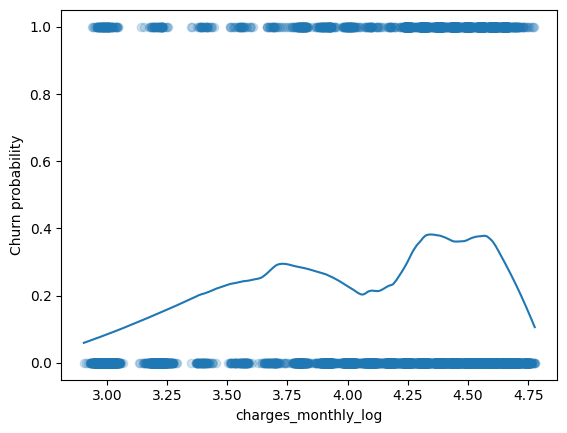

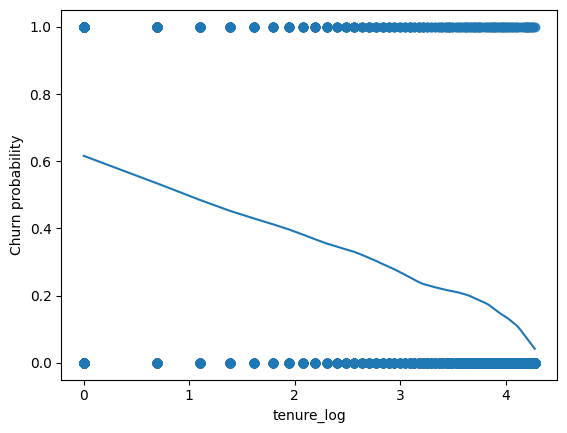

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


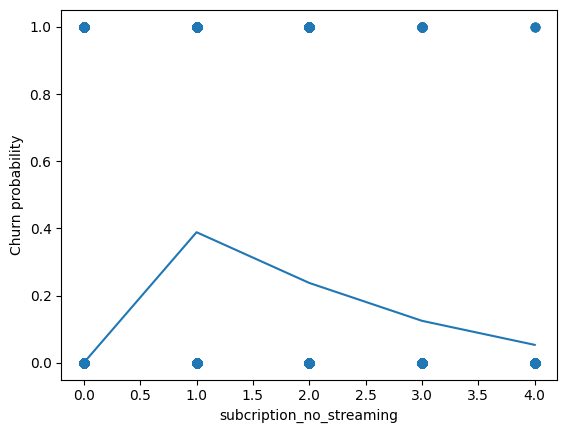

In [21]:
for var in num_vars:
  LoessPlot(var)





# Preparación de la base

## Separación en base de entrenamiento y base de prueba

La base de entrenamiento será utilizada para construir los modelos y afinar sus hoperparámetros. Adicionalemente nos brindan una primera estimación de su capacidad predictiva.

La base de prueba consiste en un 20% de los datos, separados y que nunca son utilizados por los modelos. Permiten realizar una estiamción insesgada de la capacidad predictiva de los mismos y la selección final.

In [22]:
from sklearn.model_selection import train_test_split

target = "churn"

X = df.drop(columns=[target])  # predictors
y = df[target]                 # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% test
    random_state=42,      # reproducible
    stratify=y            # Respeta la proporción en la variable respuesta
)

Se chequea que la proporción de cancelaciones se haya mantenido:

In [23]:
y_train.value_counts(normalize=True)

,proportion
churn,
0,0.734222
1,0.265778


In [24]:
y_test.value_counts(normalize=True)

,proportion
churn,
0,0.734186
1,0.265814


## Validación cruzada

Los datos de entrenamiento se subdividen en 10 grupos. 9 de ellos se utilizan para ajustar cada modelo y el restante para estimar su desempeño. Esto se repite 10 veces, dejando un grupo distinto afuera cada vez.
La estimación final es el promedio de cada una de las 10 estimaciones.

In [25]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


## Normalización de variables

Se realizan dos tipos de normalizaciones para poder ajustar los modelos:

- Estandarización: se substrae la media y se divide por el desvío estandar. Esto iguala la variabilidad de todas las variables, igualando sus pesos para los distintos modelos.
- Escala al rango 0-1: Redes Neuronales precisa de variables en el rango 0-1, por lo que se resta el mínimo y se divide por le rango a las variables continuas

### Estandarización de las variables numéricas



In [26]:
# Compute parameters using TRAIN data only
mean_vals = X_train[num_vars].mean()

sd_vals = np.sqrt(X_train[num_vars].var() )

# Avoid division by zero
sd_vals[sd_vals == 0] = 1


# Copy datasets (to keep non-numerical variables unchanged)
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()


# Scale only numerical variables
X_train_scaled[num_vars] = (X_train[num_vars] - mean_vals) / sd_vals
X_test_scaled[num_vars]  = (X_test[num_vars]  - mean_vals) / sd_vals


# Save parameters
scaling_params_num = pd.DataFrame({
    "mean": mean_vals,
    "sd": sd_vals
})

scaling_params_num.to_csv("num_scaling_parameters.csv")

### Estandarización de las variables cualitativas

Las variables cualitativas binarias (que toman valores 0 u 1) pueden ser escaladas para tener desvío estandar 1. Basta con dividirlas por:
$$sqrt( p * (1-p) )$$

In [27]:
# Compute parameters using TRAIN data only
p_vals = X_train[cat_vars].mean()

q_vals = 1 - p_vals

sd_vals = np.sqrt(p_vals * q_vals)

# Avoid division by zero
sd_vals[sd_vals == 0] = 1

# Scale only numerical variables
X_train_scaled[cat_vars] = (X_train[cat_vars] ) / sd_vals
X_test_scaled[cat_vars]  = (X_test[cat_vars] ) / sd_vals


# Save parameters
scaling_params_cat = pd.DataFrame({
    "sd": sd_vals,
})

scaling_params_cat.to_csv("cat_scaling_parameters.csv")


In [28]:
X_train_scaled[cat_vars].describe()

,gender_male,senior_citizen_65,partner,dependents,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,...,paperless_billing,dsl,fiber_optic,month_to_month,one_year,two_year,bank_transfer_automatic,credit_card_automatic,electronic_check,mailed_check
count,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,...,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000,5625.000000
mean,1.005884,0.439607,0.961111,0.658397,3.028496,0.861722,0.635723,0.725004,0.724433,0.637102,...,1.221575,0.723863,0.887045,1.106435,0.514129,0.562773,0.527370,0.524615,0.710220,0.548524
std,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,...,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089,1.000089
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,3.358693,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000034,0.000000,0.000000,0.000000,3.358693,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.040190,0.000000,0.000000,2.010239,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000034,0.000000,2.001574,2.177238,3.358693,2.022189,2.208735,2.104307,2.104823,2.206710,...,2.040190,2.105340,2.014384,2.010239,0.000000,0.000000,0.000000,0.000000,2.118234,0.000000
max,2.000034,2.714367,2.001574,2.177238,3.358693,2.022189,2.208735,2.104307,2.104823,2.206710,...,2.040190,2.105340,2.014384,2.010239,2.459165,2.339688,2.423573,2.430774,2.118234,2.371598


### Normalización min-max

Escala los datos para que estén en el rango 0 y 1

In [29]:
# Compute parameters using TRAIN data only
min_vals = X_train_scaled.min()
max_vals = X_train_scaled.max()
range_vals = max_vals - min_vals
# Avoid division by zero
range_vals[range_vals == 0] = 1

# Normalize
X_train_norm = X_train_scaled.copy()
X_test_norm  = X_test_scaled.copy()


X_train_norm = (X_train_norm - min_vals ) / range_vals
X_test_norm = (X_test_norm - min_vals ) / range_vals

# Avoid values below 0 or greater than 1
X_test_norm = X_test_norm.clip(0,1)

# Save parameters
scaling_params_norm = pd.DataFrame({
    "min_vals": min_vals,
    "range_vals": range_vals,
})

scaling_params_norm.to_csv("norm_scaling_parameters.csv")

# Valores de Referencia
Inicialmente se prueban dos modelos sobre los datos, entrenados sobre todo la base de entrenamiento.

Modelo base: un árbol de solo un nivel de profundidad. Este modelo simplista representa un piso que nuestros modelos deberían superar.

Modelo tope: un árbol profundo que sobreajusta los datos. Este modelo debería ser inalcanzable debido a que se entrena y prueba en el mismo conjunto de datos. Representa un techo teorico de nuestros modelos.

## Modelo base

In [30]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_validate

# Train model
model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42,
    class_weight="balanced",
)


results = cross_validate(
    model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

print("Validation AUC:", results["test_score"].mean().round(4))

Validation AUC: 0.7278


## Modelo tope

Ahora se entrena un árbol "profundo", con varios niveles, todas las variables y nodos finales pequeños, permitiendole sobreajustar. Este árbol se entrena y prueba con todos los datos de entrenamiento, por lo que su desempeño no debería poder ser igualado (los demás modelos utilizarán validación cruzada, es decir se entrenan con una parte de los datos y se prueban en la otra).

In [31]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Train model
model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,  #1% de la muestra, previene la memorización, pero fomenta el overfit
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

# Predict probabilities
y_pred_prob = model.predict_proba(X_train_scaled)[:,1]

# Compute AUC
auc = roc_auc_score(y_train, y_pred_prob).round(4)

print("Training AUC:", auc)

Training AUC: 0.8928


Los modelos deberían alcanzar el 0.73 de AUC como mínimo.
Ningún modelo debería alcanzar el 0.89 de AUC.

# Modelos
Se probarán los siguientes modelos:
- Árbol de decisión
- Bosques aleatorios
- Potenciador del gradiente basado en histogramas (Histogram-based GradientBoost)
- Logit con regularización
- Logit con splines y regularización
- Naive Bayes
- Redes Neuronales
- K Vecinos más cercanos
- Maquina de Soporte de vectos (Support vector machine)
- Ensambles


## Árbol de decisión

Modelo sencillo y de fácil visualización. En cada paso divide el conjunto de datos en subconjuntos (nodos), buscando que estos sean lo más homogéneos posibles, es decir, que contengan principalmente clientes que cancelaron o principalmente clientes que no cancelaron. Luego subdivide estos nodos siguiendo el mismo criterio una y otra vez.

Para evitar que el árbol siga subdividiendo hasta quedar con nodos muy pequeños, se introduce un costo o penalización por complejidad. De esta forma, una subdivisión sólo se realiza si mejora suficientemente la calidad del modelo.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


# Utilizamos un modelo para identificar los alfas (costo de complejidad)

tree = DecisionTreeClassifier(
    max_depth=7,                  # 2^7 = 128  ;  5000 muestras partido 128 = 39
    min_samples_split=50,         # un 1% de la muestra, previene el sobreajuste.
    random_state=42,
    class_weight="balanced"
)


path = tree.cost_complexity_pruning_path(X_train_scaled, y_train)

alphas = path.ccp_alphas


# ---------- 10-fold cross-validation ----------


mean_scores = []
std_scores = []


for alpha in alphas:

    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
        min_samples_split=50,   #un 1% de la muestra, previene el sobreajuste.
        max_depth = 7 ,    # Estamos utilizando alrededor de 5000 obervacions, para no llegar a nodos de tamaño 50 hay que dividir por 100 -->  2^7 = 128, la mitad de las variables, previene el sobreajuste.
        class_weight="balanced"   # Invertimos el 63:27  de churn 0 vs 1
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="roc_auc"   #Utilizamos el AUC como criterio, puesto que balancea la predicción en ambas categorias
    )

    mean_scores.append(scores.mean())
    std_scores.append(scores.std())


mean_scores = np.array(mean_scores)  #convierte en array
std_scores = np.array(std_scores)    #convierte en array


# ---------- 1-SE rule ----------

best_index = np.argmax(mean_scores)
best_score = mean_scores[best_index]
best_se = std_scores[best_index] / np.sqrt(10)


threshold = best_score - best_se


# Choose simplest model within threshold

candidate_indices = np.where(mean_scores >= threshold)[0]

alpha_1se = alphas[candidate_indices[-1]]


print("Best alpha:", alphas[best_index])
print("1SE alpha:", alpha_1se)

Best alpha: 0.0017322426102876314
1SE alpha: 0.0023152650893169743


In [ ]:
auc_1se = mean_scores[candidate_indices[-1]]

print("Cross-validated AUC (1SE model):", auc_1se)

NameError: name 'mean_scores' is not defined

In [32]:


best_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=0.0023152650893169743,
    min_samples_split=50,
    max_depth=7,
    class_weight="balanced"
)

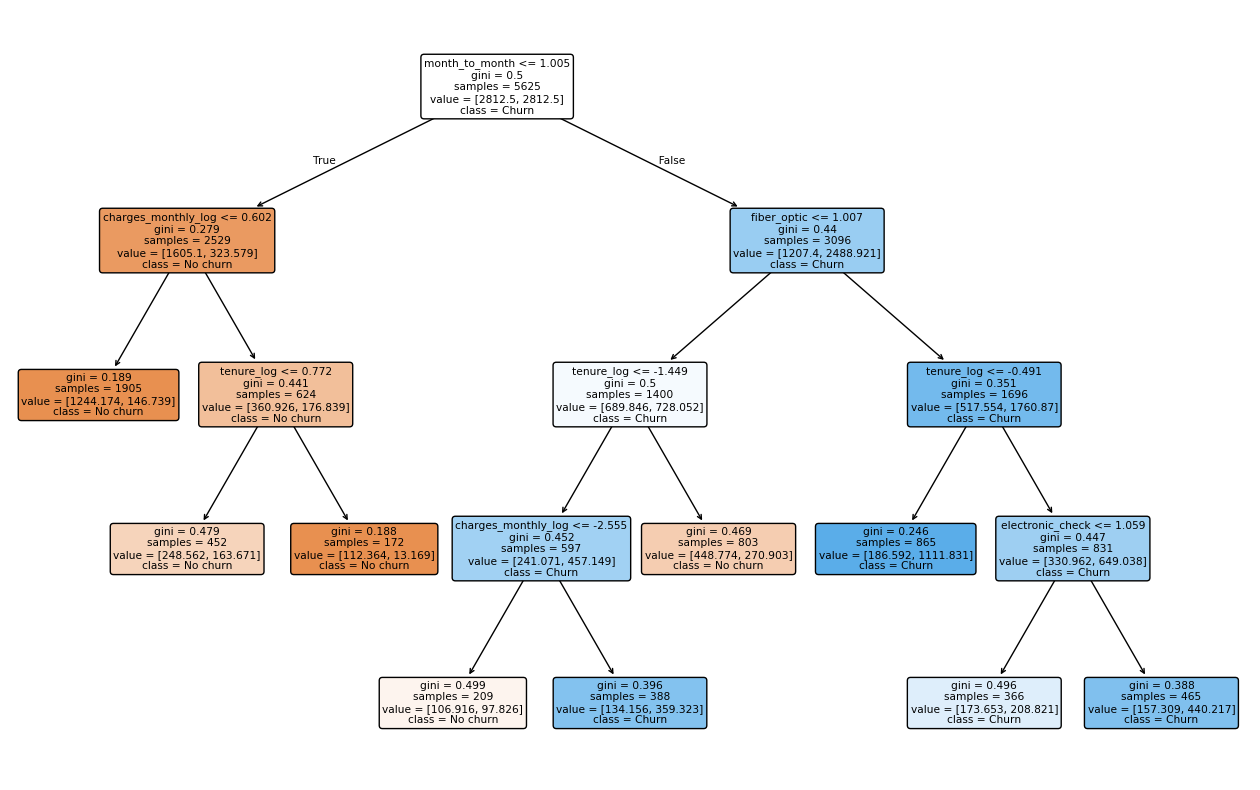

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16,10))
final_tree = best_tree.fit(X_train_scaled, y_train)
plot_tree(
    final_tree,
    feature_names=X_train.columns,
    class_names=["No churn","Churn"],
    filled=True,
    rounded=True,
    max_depth=7
)

plt.show()

## Bosque Aleatorio

En lugar de entrenar un solo árbol este método entrena cientos de árboles. Cada uno utiliza solo una porción (elegida al azar) de los datos y en cada nodo (división) solo puede usar un parte de las variables (también elegida al azar). Cada árbol entonces está utilizando una parte de los datos y en cada momento una parte de las variables, lo que le confiere una vista única de los datos.

Para la estimación final, se combinan los resultados de todos los árboles (de ahí el nombre de "bosque").

In [ ]:

param_grid = {

    "n_estimators": [100, 250, 500, 1000],
    "max_features": [4, 8, 12, 16],
    "max_depth": [1, 2, 4, 8]

}


rf_base = RandomForestClassifier(
    min_samples_split=50,     # 1% rule
    class_weight="balanced",
    random_state=42,
    n_jobs=-1   # use all CPU cores
)



grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train_scaled, y_train)

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV AUC:")
print(grid.best_score_)



Best parameters:
{'max_depth': 8, 'max_features': 8, 'n_estimators': 500}

Best CV AUC:
0.8450102431599417


In [33]:

best_rf = RandomForestClassifier(
    min_samples_split=50,     # 1% rule
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,   # use all CPU cores
    n_estimators=500,
    max_features=8,
    max_depth=8
)



## Potenciador de Gradiente Basado en Histogramas (Histogram Gradient Boost)

Este método es un modelo basado en árboles de decisión que construye una secuencia de árboles pequeños. Primero se estima un árbol inicial y se realizan las predicciones. Luego se construyen nuevos árboles que intentan corregir los errores del modelo anterior. De esta forma, cada nuevo árbol mejora gradualmente las predicciones existentes.

Este proceso se repite muchas veces hasta que el modelo deja de mejorar.

Para evitar que el modelo aprenda demasiado rápido y termine ajustándose demasiado a los datos, se limita la influencia de cada árbol sobre la predicción total.

La versión basada en "histogramas" agrupa los valores de las variables numéricas en intervalos antes de construir los árboles. Esto permite que el modelo sea mucho más rápido de entrenar sin perder demasiada precisión.

In [ ]:



# ---------- Base Model ----------

hgb_base = HistGradientBoostingClassifier(
    max_iter=1000,              # Maximum number of trees
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,        # Stop after 50 rounds without improvement
    random_state=42
)


# ---------- Parameter Grid ----------
param_grid = {
    "max_depth":[1,2,3],
    "learning_rate":[0.01,0.05,0.10],
    "max_iter":[1000],
    "min_samples_leaf":[100, 500, 1000],     # Equivalent to your min_split idea
    "l2_regularization":[0,0.01,0.1]
}
# ---------- Grid Search ----------

grid_hgb = GridSearchCV(
    estimator=hgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,              # Your existing CV object
    n_jobs=-1,
    verbose=2
)
# ---------- Fit Model ----------

grid_hgb.fit(
    X_train_scaled,
    y_train
)


# ---------- Results ----------

print("\nBest parameters:")
print(grid_hgb.best_params_)


print("\nBest CV AUC:")
print(grid_hgb.best_score_)


Fitting 10 folds for each of 81 candidates, totalling 810 fits

Best parameters:
{'l2_regularization': 0.1, 'learning_rate': 0.05, 'max_depth': 1, 'max_iter': 1000, 'min_samples_leaf': 100}

Best CV AUC:
0.8467043892292443


In [34]:

best_hgb = HistGradientBoostingClassifier(
    max_iter=1000,              # Maximum number of trees
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=100,        # Stop after 50 rounds without improvement
    random_state=42,
    max_depth = 1,
    learning_rate= 0.05,
    min_samples_leaf= 50,     # Equivalent to your min_split idea
    l2_regularization= 0.1

)

## Regresión Logística

Un modelo clásico de la estadística tradicional. En lugar de modelar directamente las probabilidades, se modela el logaritmo de las odds (razón de probabilidades).

Por ejemplo, en lugar de utilizar una probabilidad de 0.80, se pueden usar odds de 4:1 (y aplicar luego un logaritmo). Este procedimiento permite utilizar métodos matemáticos muy similares a los de la regresión lineal.

$$ log( odds) = B_0 + B_1 X_1 + B_2 X_2 + ... + B_k X_k $$

A partir de esta ecuación se pueden obtener las probabilidades estimadas de cancelación para cada cliente.

In [ ]:
# ---------- Base Model ----------

logit_base = LogisticRegression(

    max_iter=5000,          # Ensure convergence
    class_weight="balanced",   # Handle imbalance
    solver="liblinear",     # Stable and reliable
    random_state=42
)


# ---------- Parameter Grid ----------

param_grid = {

    "C":[
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "penalty":[  "l1",   "l2"  ]

}


# ---------- Grid Search ----------

grid_logit = GridSearchCV(
    estimator=logit_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)


# ---------- Fit Model ----------

grid_logit.fit(
    X_train_scaled,
    y_train
)


# ---------- Results ----------

print("\nBest parameters:")
print(grid_logit.best_params_)


print("\nBest CV AUC:")
print(grid_logit.best_score_)




Fitting 10 folds for each of 12 candidates, totalling 120 fits

Best parameters:
{'C': 0.01, 'penalty': 'l2'}

Best CV AUC:
0.8484717487040317


['logistic_model.pkl']

In [35]:
best_logit = LogisticRegression(

    max_iter=5000,          # Ensure convergence
    class_weight="balanced",   # Handle imbalance
    solver="liblinear",     # Stable and reliable
    random_state=42,
    C = 0.01,
    penalty = "l2"
)




0.84 again? could this be the ceeling?

## Regresión logística con Splines

Alternativa a la regresión logística, se añaden puntos de corte en las variables numéricas para poder modelarlas más facilmente.
No se encontró una mejora.


In [ ]:
X_train_spline = X_train_scaled.copy()

# usa X_train por no estar estandarizada

knot = (X_train["charges_monthly_log"] > np.log(39.5)  ).astype(int)
X_train_spline["knot_40"] = knot
X_train_spline["charges_monthly_log_knot_40"] = knot * X_train_spline["charges_monthly_log"]


knot = (X_train["charges_monthly_log"] > np.log(59.5)  ).astype(int)
X_train_spline["knot_60"] = knot
X_train_spline["charges_monthly_log_knot_60"] = knot * X_train_spline["charges_monthly_log"]


knot = (X_train["charges_monthly_log"] > np.log(74.5)  ).astype(int)
X_train_spline["knot_75"] = knot
X_train_spline["charges_monthly_log_knot_75"] = knot * X_train_spline["charges_monthly_log"]


knot = (X_train["charges_monthly_log"] > np.log(99.5)  ).astype(int)
X_train_spline["knot_100"] = knot
X_train_spline["charges_monthly_log_knot_100"] = knot * X_train_spline["charges_monthly_log"]


In [ ]:
X_train_spline.head()

,gender_male,senior_citizen_65,partner,dependents,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,...,electronic_check,mailed_check,knot_40,charges_monthly_log_knot_40,knot_60,charges_monthly_log_knot_60,knot_75,charges_monthly_log_knot_75,knot_100,charges_monthly_log_knot_100
1416,2.000034,0.000000,2.001574,0.000000,3.358693,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0,-0.000000,0,-0.000000,0,-0.000000,0,-0.000000
6993,2.000034,0.000000,2.001574,2.177238,3.358693,0.000000,2.208735,0.000000,0.000000,2.20671,...,2.118234,0.000000,1,0.730229,1,0.730229,1,0.730229,1,0.730229
3417,0.000000,2.714367,0.000000,0.000000,3.358693,0.000000,0.000000,0.000000,2.104823,0.00000,...,2.118234,0.000000,1,0.102124,1,0.102124,0,0.000000,0,0.000000
4559,2.000034,0.000000,2.001574,0.000000,3.358693,0.000000,2.208735,2.104307,0.000000,2.20671,...,0.000000,2.371598,1,-0.042279,1,-0.042279,0,-0.000000,0,-0.000000
3604,0.000000,0.000000,2.001574,2.177238,3.358693,2.022189,2.208735,0.000000,0.000000,0.00000,...,0.000000,0.000000,1,-0.159902,1,-0.159902,0,-0.000000,0,-0.000000


In [ ]:
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


# ---------- Base Model ----------

logit_base = LogisticRegression(

    max_iter=5000,          # Ensure convergence

    class_weight="balanced",   # Handle imbalance

    solver="liblinear",     # Stable and reliable

    random_state=42
)


# ---------- Parameter Grid ----------

param_grid = {

    "C":[
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "penalty":[ "l1",  "l2" ]

}


# ---------- Grid Search ----------

grid_logit = GridSearchCV(

    estimator=logit_base,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=cv,              # Your cross-validation object

    n_jobs=-1,

    verbose=2

)


# ---------- Fit Model ----------

grid_logit.fit(

    X_train_spline,

    y_train

)


# ---------- Results ----------

print("\nBest parameters:")

print(grid_logit.best_params_)


print("\nBest CV AUC:")

print(grid_logit.best_score_)


# ---------- Store Model ----------

best_logit = grid_logit.best_estimator_

joblib.dump(best_logit,"logistic_model.pkl")

Fitting 10 folds for each of 12 candidates, totalling 120 fits

Best parameters:
{'C': 0.01, 'penalty': 'l2'}

Best CV AUC:
0.8486114695224011


['logistic_model.pkl']

0.84 --> No mejora por tener splines

## Máquina de vector soporte (Support Vector Machine)

Este método busca encontrar una frontera que separe lo mejor posible a los clientes que cancelan de los que no cancelan. A diferencia de otros modelos, la Máquina de Vector Soporte intenta que la separación no sólo sea correcta, sino que además deje el mayor margen posible entre ambos grupos, lo que suele mejorar la capacidad de generalización.

En muchos casos los datos no pueden separarse fácilmente con una línea recta. Para resolver esto, el método puede transformar los datos a un espacio de mayor dimensionalidad, donde la separación resulta más sencilla.

Como ayuda visual, si en una hoja ponemos varios puntos de dos colores, puede ser muy difícil o incluso imposible encontrar una línea que separe ambos colores perfectamente. Pero si se nos permite doblar la hoja libremente ( aumentar la dimensionalidad), entonces dividir los puntos se vuelve mucho más sencillo.

In [ ]:
# ---------- Base Model ----------

svm_base = SVC(
    probability=True,        # Needed for ROC AUC
    class_weight="balanced",
    random_state=42
)


# ---------- Parameter Grid ----------

param_grid = {

    "C":[1,10],
    "kernel":["rbf"],
    "gamma":[ "scale", 0.01, 0.1 ]

}


# ---------- Grid Search ----------

grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# ---------- Fit Model ----------

grid_svm.fit(
    X_train_scaled,
    y_train,
)


# ---------- Results ----------

print("\nBest parameters:")
print(grid_svm.best_params_)

print("\nBest CV AUC:")
print(grid_svm.best_score_)


Fitting 10 folds for each of 6 candidates, totalling 60 fits


KeyboardInterrupt: 

0.84? again!

In [36]:
best_svm =  SVC(
    probability=True,        # Needed for ROC AUC
    class_weight="balanced",
    random_state=42,
    C=1,
    gamma= 0.01,
    kernel = "rbf"

)

## K Vecinos Más Cercanos

Este método consiste en identificar para cada observación las K observaciones más similares (sus vecinos). Esta similitud se basa en las variables disponibles y depende fuertemente de la escala de las mismas, de ahí la importancia de estandarizar los datos.

Para predecir si un cliente cancelará o no, simplemente se observa el comportamiento de sus vecinos: si la mayoría canceló, entonces se estima que él también cancelará.

In [ ]:
# Modelo base
knn = KNeighborsClassifier()

# Grid
param_grid = {

    "n_neighbors":[3,5,7,11,15,25,35,55,75,101,125,151,201],

    "weights":[ "uniform",  "distance" ],

    "metric":[ "euclidean",   "manhattan" ]

}

# Grid search con CV
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)



# Entrenamiento
grid_knn.fit(X_train_scaled,y_train)

# Resultados
print("Best parameters:")
print(grid_knn.best_params_)

print("\nBest CV score:")
print(grid_knn.best_score_)

# ---------- Store Model ----------

best_knn = grid_knn.best_estimator_

Best parameters:
{'metric': 'euclidean', 'n_neighbors': 125, 'weights': 'uniform'}

Best CV score:
0.837198178873415


In [37]:
best_knn = KNeighborsClassifier(
    n_neighbors=125,
    weights="uniform",
    metric="euclidean"
)

## Redes Neuronales

Este método está inspirado en el funcionamiento de las neuronas. Cada variable (edad, género, costo del plan, antigüedad, etc.) actúa como una entrada que envía información a las neuronas de la primera capa.

Estas neuronas combinan las entradas mediante operaciones matemáticas y transmiten el resultado a la siguiente capa. Este proceso se repite a lo largo de varias capas hasta llegar a una neurona final que produce una predicción de la cancelación, generalmente expresada como una probabilidad.

Al comienzo del entrenamiento, las conexiones entre neuronas tienen valores iniciales aleatorios. Durante el aprendizaje, estos valores se van ajustando para que la red pueda detectar y combinar distintos patrones presentes en los datos.

In [ ]:
# Modelo base

mlp = MLPClassifier(
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42
)


# Grid

param_grid = {
"hidden_layer_sizes":[
    (5,),
    (10,),
    (20,),
    (40,),
    (10,10),
    (20,20),
    (20,10),
    (10,10,10),
    ],
"alpha":[0.001,  0.01],
"learning_rate_init":[0.001, 0.01],
"activation":[ "relu", "tanh" ]
}


# Grid search

grid_mlp = GridSearchCV(
  estimator=mlp,
  param_grid=param_grid,
  cv=cv,
  scoring="roc_auc",
  n_jobs=-1,
  verbose=2
)


# Fit

grid_mlp.fit(
    X_train_normalized,
    y_train
    )


# Results

print("Best parameters:")
print(grid_mlp.best_params_)

print("\nBest CV score:")
print(grid_mlp.best_score_.round(4))

Fitting 10 folds for each of 32 candidates, totalling 320 fits
Best parameters:
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (40,), 'learning_rate_init': 0.001}

Best CV score:
0.8484749771140399


In [38]:
best_nn = MLPClassifier(
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=50,
    random_state=42,
    hidden_layer_sizes=(40,),
    alpha= 0.01,
    learning_rate_init=0.001,
    activation= "tanh"
)



## Clasificador Bayesiano Ingenuo

Este método asume que las variables predictoras son independientes entre sí. Bajo este supuesto, se pueden estudiar las probabilidades asociadas a cada variable por separado para los clientes que cancelaron y los que no cancelaron.

Si bien este supuesto de independencia suele ser falso (por ello se lo llama "ingenuo"), el método permite combinar la información de todas las variables para calcular matemáticamente la probabilidad de que un cliente cancele o no.

Estos cálculos se basan en el teorema de Bayes.

In [ ]:
nb = GaussianNB(priors=[0.5, 0.5])

scores = cross_val_score(
    nb,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="roc_auc"
)


print("Naive Bayes AUC:",scores.mean().round(4))

Naive Bayes AUC: 0.8348


In [39]:

best_nb = GaussianNB(priors=[0.5, 0.5])


FIT ALL MODELS

In [40]:
fit_tree = best_tree.fit(X_train_scaled,y_train)
fit_rf = best_rf.fit(X_train_scaled,y_train)
fit_hgb = best_hgb.fit(X_train_scaled,y_train)
fit_logit = best_logit.fit(X_train_scaled,y_train)
fit_svm = best_svm.fit(X_train_scaled,y_train)
fit_knn = best_knn.fit(X_train_scaled,y_train)
fit_nn = best_nn.fit(X_train_norm,y_train)
fit_nb = best_nb.fit(X_train_scaled,y_train)


## Acuerdo entre los modelos

Se grafican las probabilidades estimadas para todos los datos según cada modelo. Dos modelos tienen un acuerdo perfecto cuando forman una linea recta diagonal.

Se observa que los modelos suelen coincidir  en el patrón general aunque asignen probabilidades de forma diferente (el patrón general no forma una línea diagonal perfecta o incluso se notan algunos patrones levemente curvos).

El árbol de decisión se caracteriza por sus saltos discretos, haciendo dificil su interprtación.

Bayes Ingenuo muestra una fuerte tendencia a estimar probabilidades extremas (cero u uno), esto puede debersa a las variables correlacionadas dentro de la muestra acumulando sus efectos. No se lo recomienda para estimar probabilidades aunque no deja de ser util para clasificar.

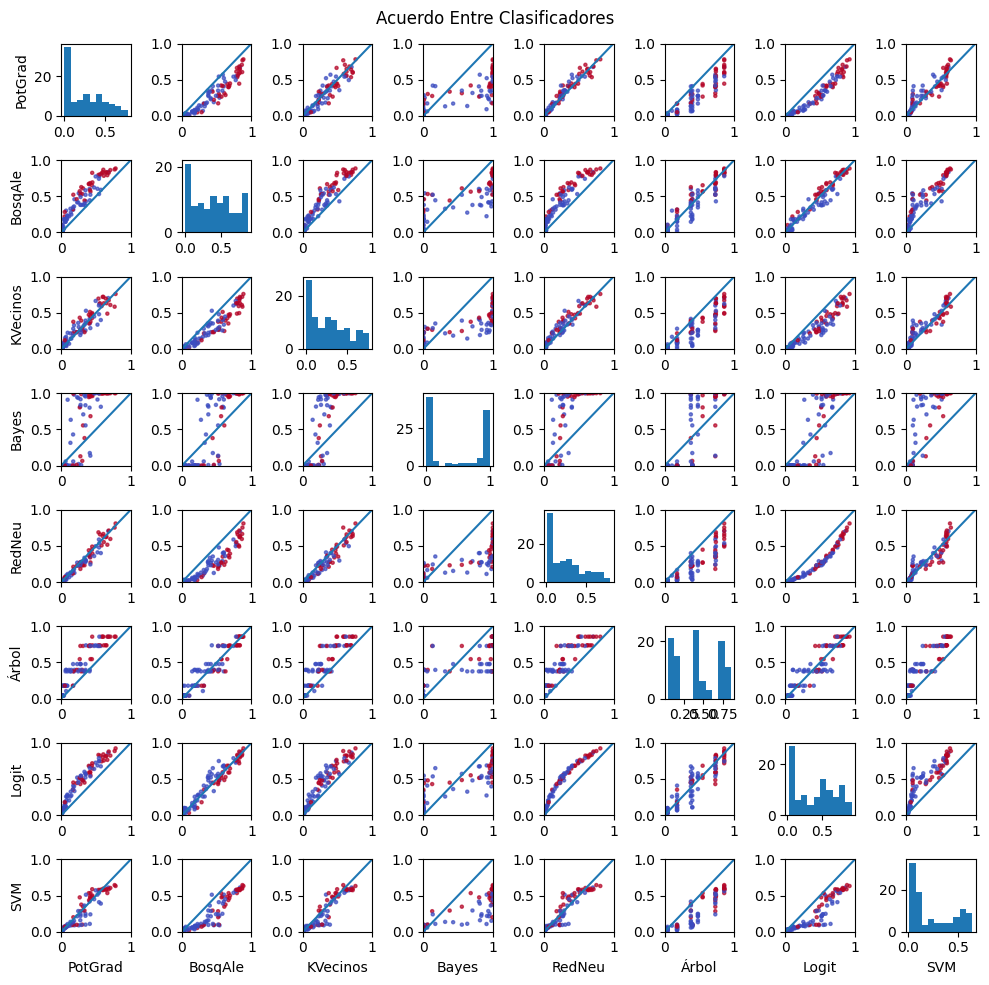

In [41]:

# ---- Extract probabilities (positive class) ----

sample = X_train_scaled.sample(n=100, random_state=42)
sample_norm = X_train_norm.sample(n=100, random_state=42)
sample_y = y_train.sample(n=100, random_state=42)

p_hgb = fit_hgb.predict_proba(sample)[:,1]
p_rf = fit_rf.predict_proba(sample)[:,1]
p_knn = fit_knn.predict_proba(sample)[:,1]
p_nb = fit_nb.predict_proba(sample)[:,1]
p_nn = fit_nn.predict_proba(sample_norm)[:,1]
p_logit = fit_logit.predict_proba(sample)[:,1]
p_tree = fit_tree.predict_proba(sample)[:,1]
p_svm = fit_svm.predict_proba(sample)[:,1]

# ---- Build dataframe ----

preds = pd.DataFrame({
    "PotGrad": p_hgb,
    "BosqAle": p_rf,
    "KVecinos": p_knn,
    "Bayes": p_nb,
    "RedNeu": p_nn,
    "Árbol": p_tree,
    "Logit": p_logit,
    "SVM": p_svm
})

# ---- Scatterplot matrix ----

models = preds.columns
n = len(models)

fig, axes = plt.subplots(n, n, figsize=(10,10))

for i in range(n):
    for j in range(n):

        ax = axes[i,j]

        if i == j:

            # Diagonal → distribution
            ax.hist(preds[models[i]], bins=10)

        else:

            # Scatterplots
            ax.scatter(
                preds[models[j]],
                preds[models[i]],
                alpha=0.7,
                s=5,
                c=sample_y,
                cmap="coolwarm"
            )

            # Agreement diagonal
            ax.plot([0,1],[0,1])

            ax.set_xlim(0,1)
            ax.set_ylim(0,1)

        # Labels

        if i == n-1:
            ax.set_xlabel(models[j])

        if j == 0:
            ax.set_ylabel(models[i])

plt.suptitle("Acuerdo Entre Clasificadores")

plt.tight_layout()

plt.show()

In [ ]:
preds.corr(numeric_only=True)

,PotGrad,BosqAle,KVecinos,Bayes,RedNeu,Árbol,Logit,SVM
PotGrad,1.000000,0.952313,0.950754,0.878085,0.975796,0.925914,0.974428,0.933133
BosqAle,0.952313,1.000000,0.951909,0.846916,0.947528,0.923451,0.970638,0.919540
KVecinos,0.950754,0.951909,1.000000,0.900363,0.954598,0.880368,0.958270,0.933736
Bayes,0.878085,0.846916,0.900363,1.000000,0.848719,0.827759,0.862181,0.941913
RedNeu,0.975796,0.947528,0.954598,0.848719,1.000000,0.894662,0.966036,0.921817
Árbol,0.925914,0.923451,0.880368,0.827759,0.894662,1.000000,0.912465,0.907737
Logit,0.974428,0.970638,0.958270,0.862181,0.966036,0.912465,1.000000,0.910404
SVM,0.933133,0.919540,0.933736,0.941913,0.921817,0.907737,0.910404,1.000000


# COMPARANDO MODELOS

Se ajustan los modelos para todo el dataset de entrenamiento. Luego se realizan las predicciones sobre el dataset de prueba.
Acompañando cada medida se encuentra los valores alcanzado por el modelo base y el modelo tope (que a diferencia de los demás, fue calculado sobre la base de entrenamiento).
Se ajustan todos los modelos para capturar el 80% de los individuos que cancelan. Esta medida se puede cambiar libremente.

In [42]:
# Ajusta todos los modelos
fit_models = {}

fit_models["Árbol"] = best_tree.fit(X_train_scaled, y_train)
fit_models["BosqAl"] = best_rf.fit(X_train_scaled, y_train)
fit_models["PotGrad"] = best_hgb.fit(X_train_scaled, y_train)
fit_models["Logit"] = best_logit.fit(X_train_scaled, y_train)
fit_models["SVM"] = best_svm.fit(X_train_scaled, y_train)
fit_models["KVecinos"] = best_knn.fit(X_train_scaled, y_train)
fit_models["RedNeu"] = best_nn.fit(X_train_norm, y_train)
fit_models["Bayes"] = best_nb.fit(X_train_scaled, y_train)

In [43]:
preds = {}
probs = {}
thereshold={"Árbol": 0.5, "BosqAl": 0.5, "PotGrad": 0.5 , "Logit": 0.5, "SVM": 0.5, "KVecinos":0.5, "RedNeu": 0.5, "Bayes": 0.5}
for name, model in fit_models.items():
  if name != "RedNeu":
    probs[name] = model.predict_proba(X_test_scaled)[:,1]
    preds[name] = (probs[name] > thereshold[name]).astype(int)
  else:
    probs[name] = model.predict_proba(X_test_norm)[:,1]
    preds[name] = (probs[name] > thereshold[name]).astype(int)



Seteando el recall a 80%

In [44]:
thresholds = {}
precision80 = {}
recall80 = {}
target_recall = 0.8

for name, model in fit_models.items():
    probs_model = probs[name]
    for i in range(1001):

        threshold = round(1.0 - i/1000, ndigits=3)

        preds[name]= (probs_model > threshold).astype(int)

        rec = recall_score(y_test, preds[name], pos_label=1)

        if rec >= target_recall:

            thresholds[name] = threshold
            recall80[name] = rec

            precision80[name] = precision_score(
                y_test,
                preds[name],
                pos_label=1
            )

            break

In [45]:
print(thresholds)

{'Árbol': 0.397, 'BosqAl': 0.477, 'PotGrad': 0.276, 'Logit': 0.517, 'SVM': 0.255, 'KVecinos': 0.311, 'RedNeu': 0.277, 'Bayes': 0.698}


In [46]:
results = []

for name in fit_models:

    y_pred = preds[name]
    y_prob = probs[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test,y_pred),
        "AUC": roc_auc_score(y_test,y_prob),
        "Precision_0": precision_score(y_test,y_pred,pos_label=0),
        "Precision_1": precision_score(y_test,y_pred,pos_label=1),
        "Recall_0": recall_score(y_test,y_pred,pos_label=0),
        "Recall_1": recall_score(y_test,y_pred,pos_label=1),
        "F1": f1_score(y_test,y_pred)
    })

results_df = pd.DataFrame(results)

Modelos de referencia

In [47]:
baseline = DecisionTreeClassifier(
    max_depth=1,
    class_weight="balanced",
    random_state=42
)

baseline.fit(X_train_scaled,y_train)

baseline_prob = baseline.predict_proba(X_test_scaled)[:,1]


ceiling = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_leaf=30,
    class_weight="balanced"
)

ceiling.fit(X_train_scaled,y_train)

ceiling_prob = ceiling.predict_proba(X_train_scaled)[:,1]

threshold

In [48]:
target_recall = 0.80
for i in range(1001):
        threshold = round(1.0 - i/1000, ndigits=3)
        baseline_pred= (baseline_prob > threshold).astype(int)
        rec = recall_score(y_test, baseline_pred, pos_label=1)
        if rec >= target_recall:
          print(threshold)
          break

for i in range(1001):
        threshold = round(1.0 - i/1000, ndigits=3)
        ceiling_pred = (ceiling_prob > threshold).astype(int)
        rec = recall_score(y_train, ceiling_pred, pos_label=1)
        if rec >= target_recall:
          print(threshold)
          break

0.673
0.542


In [49]:


baseline_metrics = {

"Accuracy": accuracy_score(y_test,baseline_pred),
"AUC": roc_auc_score(y_test,baseline_prob),
"F1": f1_score(y_test,baseline_pred),
"Precision_0": precision_score(y_test,baseline_pred,pos_label=0),
"Precision_1": precision_score(y_test,baseline_pred,pos_label=1),
"Recall_0": recall_score(y_test,baseline_pred,pos_label=0),
"Recall_1": recall_score(y_test,baseline_pred,pos_label=1),
}

ceiling_metrics = {

"Accuracy": accuracy_score(y_train,ceiling_pred),
"AUC": roc_auc_score(y_train,ceiling_prob),
"F1": f1_score(y_train,ceiling_pred),
"Precision_0": precision_score(y_train,ceiling_pred,pos_label=0),
"Precision_1": precision_score(y_train,ceiling_pred,pos_label=1),
"Recall_0": recall_score(y_train,ceiling_pred,pos_label=0),
"Recall_1": recall_score(y_train,ceiling_pred,pos_label=1),
}

In [50]:
def plot_metric(metric,  title ):
    cut=0

    values = results_df[metric]
    plt.figure()
    plt.barh(
        results_df["Model"],
        values
    )

    plt.xlabel(metric)
 # Add value labels
    offset = max(values) * (-0.1)

    for i, v in enumerate(values):

        plt.text(
            v + offset,   # slightly right of bar
            i,
            f"{v:.3f}",   # 3 decimals
            va="center",
            c = "white"
        )
    plt.axvline(
        baseline_metrics[metric],
        linestyle="--"
    )

    plt.axvline(
        ceiling_metrics[metric],
        linestyle=":"
    )
    plt.title(title)

    plt.show()


## Recall / Sensibilidad

Este valor mide el porcentaje de clientes que cancelaron que fueron correctamente identificados. Podemos pensar este estadístico en que tantos clientes que cancelaran son "capturados" por nuestro modelo. Como criterio se seleccionó un punto de corte para cada modelo tal que se pudieran capturar el 80% de los clientes que cancelan.
Nuevamente de ser necesario este valor se puede reajustar según los objetivos de la companía.
Notamos que los arboles de decisión, por su naturaleza discreta, se mantienen levemente arriba del 80% por lo que se espera que pierda Precisión

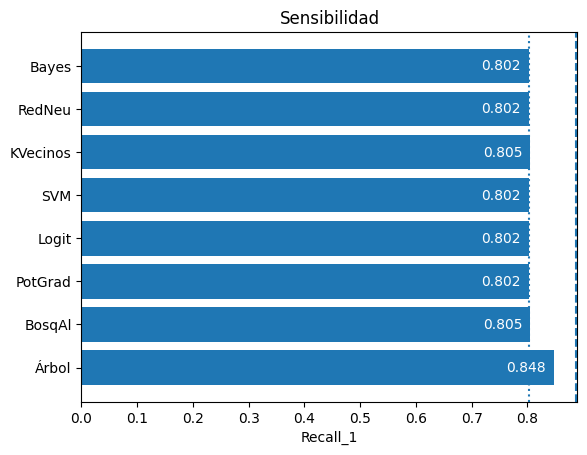

In [ ]:
plot_metric("Recall_1", title = "Sensibilidad")


## PRECISIÓN

Mide la probabilidad de que un cliente etiquetado como "alto riesgo de cancelación", realmente cancele. La mayoría de los modelos se encuentran entre el 49% y el 53%. Nuevamente los modelos Redes Neuronales, Regresión Logística y Bosque Aleatorio alcanzan los valores superiores (arriba de 52.5%)

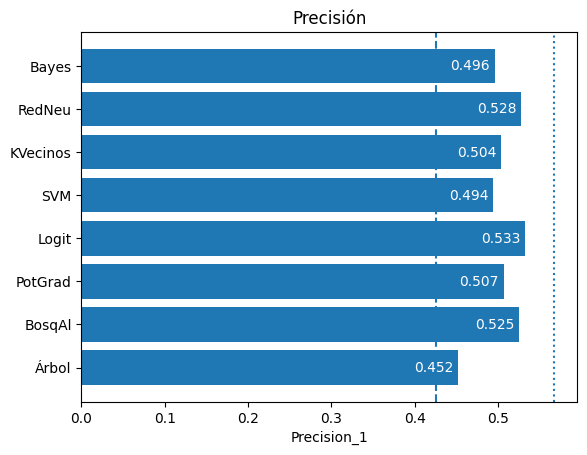

In [ ]:
plot_metric("Precision_1", title = "Precisión")

## F1

El estadístico F1 representa una especie de promedio entre la capacidad del modelo de detectar a los clientes que cancelan y la probabilidad de que un cliente identificado como que cancelará realmente lo haga. Ambos conceptos serán explorados más adelante.

Todos los modelos salvo el árbol de decisión presentan F1 entre 61% y 64%. Nuevamente Redes Neuronales, Regresión Logística y Bosque Aleatorio alcanzan los mayores valores ( superiores a 63.5%).


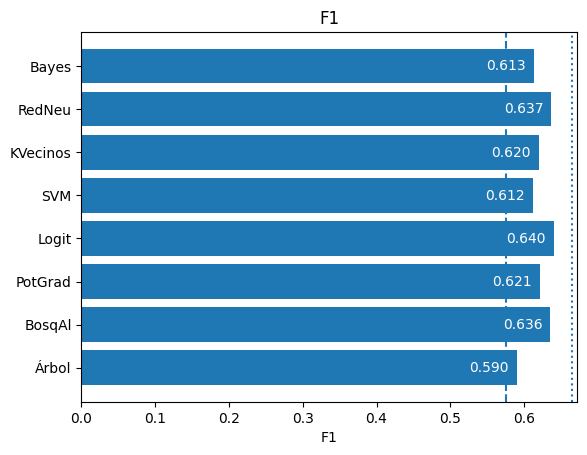

In [ ]:
plot_metric("F1", title = "F1")

## Exactitud / Acuracía

Esta métrica representa que tantas veces el modelo acierta en su predicción (si el cliente cancela o no). Esta métrica da mayor importancia a la clase mayoritaria (sin cancelar) por lo que debe ser interpretada con cuidado.

Salvo el árbol de decisión todos los modelos  se encuentran entre el 73% y 76% de exactitud. Entre ellos los modelos de Redes Neuronales, Regresión Logística y Bosque Aleatorio alcanzan exactitud arriba del 75.5%.

Estas porcentajes se encuentran muy cerca del límite teórico de 78%.

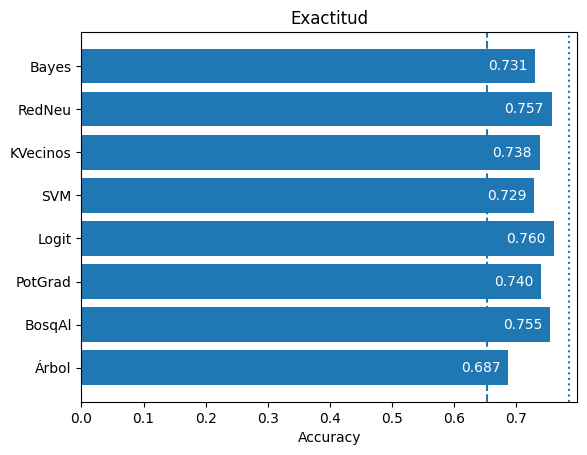

In [ ]:
plot_metric("Accuracy", title = "Exactitud")

## AUC

El area bajo la curva ROC mide la capacidad predictiva del modelo en ambas clases, independientemente de el punto de corte elegido*. Nuevamente nos encontramos con valores muy similares: entre 82% y 85%. Y los modelos Potenciador de Gradiente, Redes Neuronales, Regresión Logística y Bosque Aleatorio alcanzan valores superiores al 84.5%.

Este análisis lo realizamos con un punto de corte tal que capturamos al 80% de los clientes que cancelan (recall = 80%). Al cambiar el punto de corte los demás estadísticos pueden cambiar pero no el AUC.

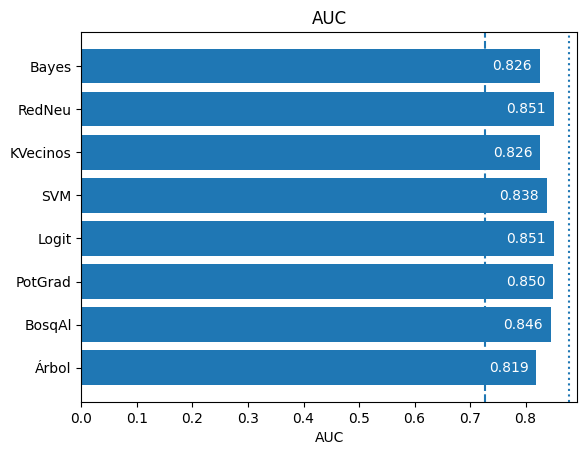

In [ ]:
plot_metric("AUC", title ="AUC")

## Matriz de confuión


Las matrices de confusión nos permiten observar varios estadísticos a la vez: los valores bien y mal clasificados dentro de ambas categorías.

Simplemente con ver los colores nos damos cuenta de la enorme simulitud entre los modelos. Exceptuando al árbol de decisión (y a su conocido problema con los saltos discretos de probabilidad) todos los modelos demuestran características similares.

Para empezar notamos que los verdaderos de la línea inferior son todos iguales: 74 y 300. Estos son los verdaderos positivos (Predicho = 1, Real=1) y los falsos negaticos (Predicho = 0, Real = 1). Esto se debe a que fijamos nuestros modelos para que capturen al 80% de los positivos, de los clientes que cancelan.

Comparemos entonces la parte superior de las matrices. Observamos que los modelos Logit, Bosque Aleatorio y Redes Neuronales son los que mejor funcionan, obteniendo la mayor cantidad de verdaderos negaticos (predicho=0, real = 0), todos entre 760 y 770 y consecuentemente la menor cantidad de falsos positivos (predicho =1, real=0) entre 263 y 272.



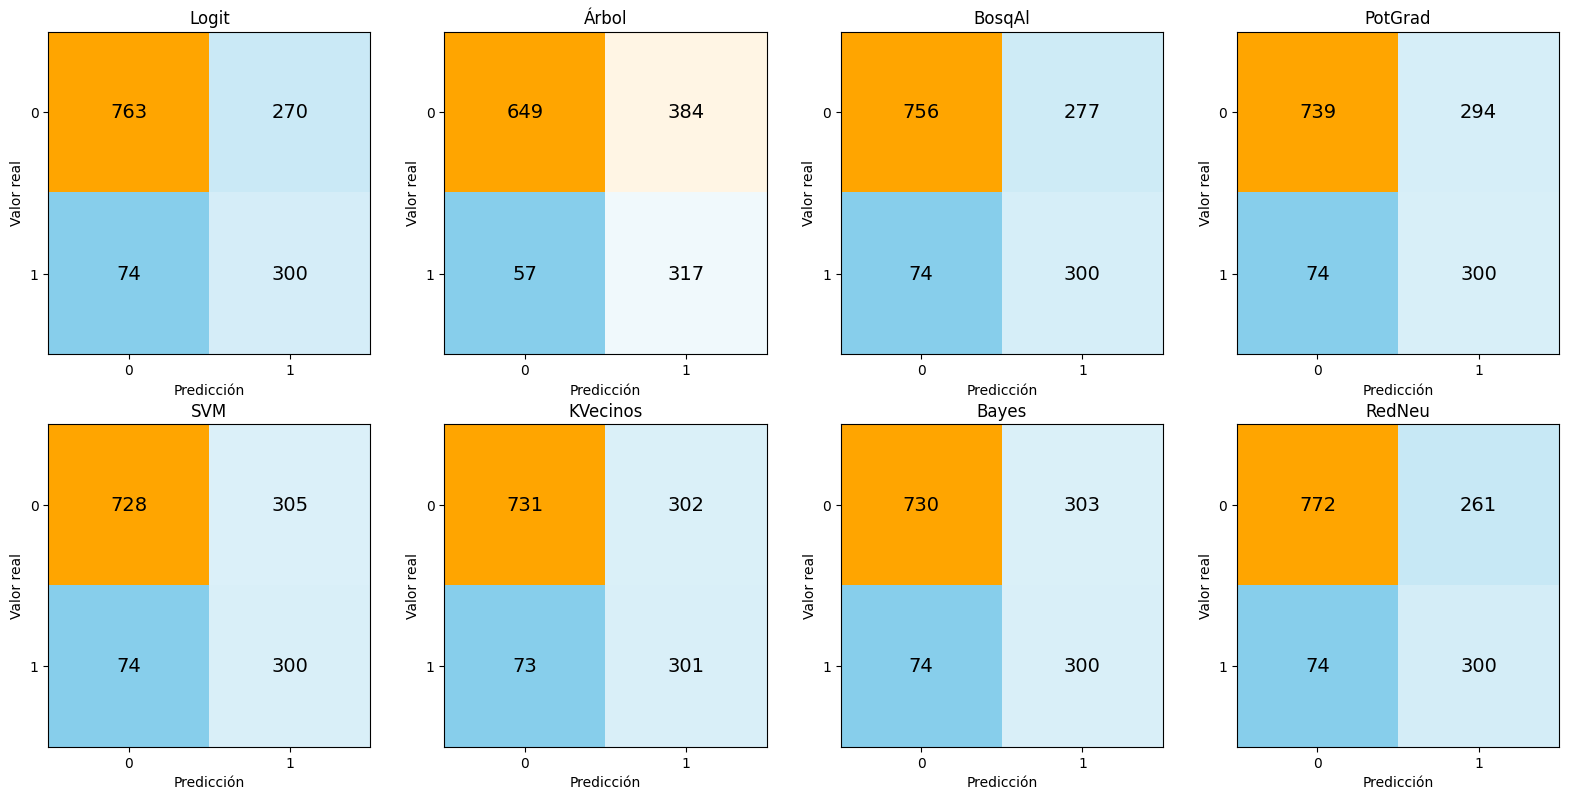

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Colores discretos
#colors = [ "skyblue", "white", "orange"]
colors = [ "blue", "white", "red"]
cmap =  LinearSegmentedColormap.from_list("custom", colors)


models = ["Logit","Árbol","BosqAl","PotGrad","SVM","KVecinos","Bayes","RedNeu"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, model in zip(axes.flatten(), models):

    cm = confusion_matrix(y_test, preds[model])

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(
        ax=ax,
        cmap=cmap,
        text_kw = {"color": "black", "fontsize": 14},
        colorbar=False
    )

    ax.set_title(model)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

## Decisión Final

Salvo el árbol de decisión, todos los modelos presentaron un desempeño principal, con una leve ventaja de los modelos Redes Neuronales, Bosque Aleatorio y Regresión Logística.
Los valores de AUC de estos modelos se encuentran muy cerca de los estimados durante el entrenamiento, lo cual indica que no hay sobreajueste y además se encuentran muy cerca del límite superior, lo cual indica que el modelo captura todos la información relevante de los datos.
Entre estos tres modelos se seleccionará el más sencillo: Regresión Logística. Este modelo presenta muchas ventajas adicionales, principalmente permite observar el efecto de cada variable individualmente y su relación con las estimaciones.

In [28]:
np.exp( X_train["charges_monthly_log"].median() )

np.float64(70.35)

# Interpretación del Modelo

A partir de los coeficientes brindados por el modelo podemos interpretar que los factores más importantes son:
- La antigüedad del cliente.
- El tipo de contrato (mensual, anual, bianual)
- Los gastos mensuales
- El tipo de internet (fibra óptica, DSL, sin internet).

Además, utilizando el modelo para estimar la probabilidad se puede obtener que:

**A mayor antigüedad la cancelación disminuye.**
- Un cliente típico nuevo tiene una probabilidad del 62%  de cancelar, un cliente de 6 meses tiene 41%, un cliente de un año de antigüedad tiene 34%.

**A mayor gasto mensual la cancelación se incrementa.**
- Un cliente típico con gastos mensuales de $30 tiene una probabilidad de 15% de cancelar. Con un plan de $60 la probabilidad es de 23% y de $90 es del 28%.

**A mayor tiempo de contratación la cancelación disminuye**
- Un cliente típico con contrato menusal tiene una probabilidad del 25%  de cancelar. Con un contrato anual pasa a 13% y bianaual al 7%

**El servicio de internet influye **
- Un cliente típico con fibra óptica tiene una probabilidad de 37% de cancelar. Mietnras que aquellos con DSL o sin internet tienen un 25%.


*Nota: Debido a que durante el entrenemiento se dió la misma importancia a los clientes que cancelaron como a los que no el modelo tiende a inflar las probabilidades de cancelación (para compensar el desbalance). Para que esto no afecte nuestras estimaciones se realiza una calibración, explicada más adelante*

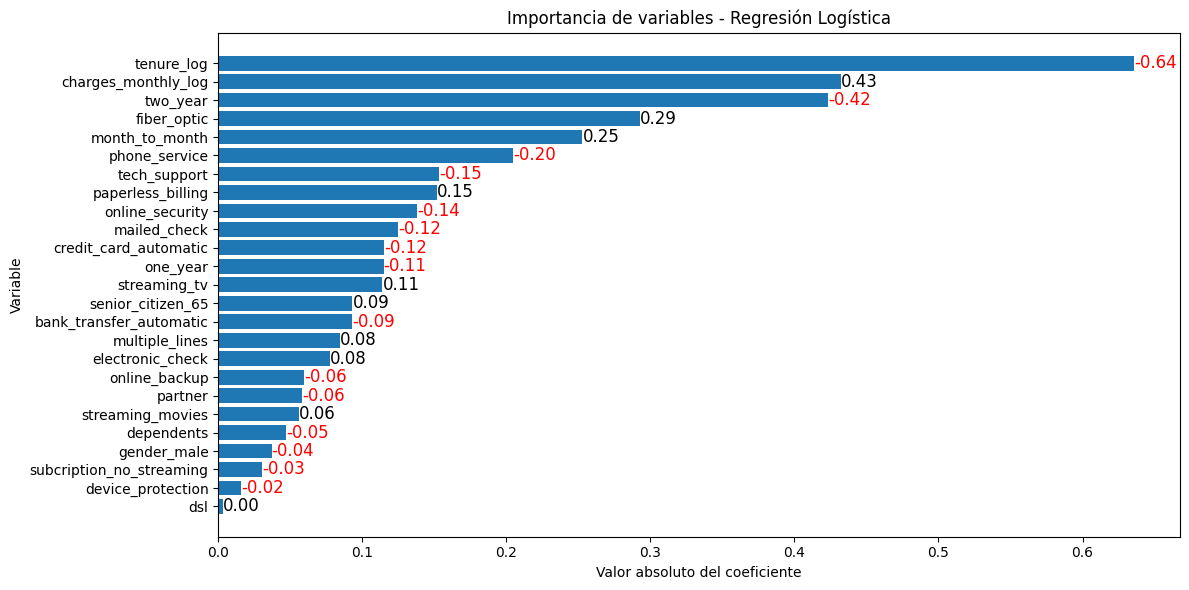

In [43]:
coef_table = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": best_logit.fit(X_train_scaled, y_train).coef_[0],

})

coef_table["AbsCoef"] = np.abs(coef_table["Coeficiente"])

# Ordenar para que quede prolijo
coef_plot = coef_table.sort_values("AbsCoef")

# Crear gráfico
plt.figure(figsize=(12,6))

bars = plt.barh(
    coef_plot["Variable"],
    coef_plot["AbsCoef"],
)

# Agregar etiquetas numéricas
for i, v in enumerate(coef_plot["Coeficiente"]):
    plt.text(
        abs(v),
        i,
        f"{v:.2f}",
        va="center",
        ha="left",
        fontsize=12,
        color="red" if v < 0 else "black"
    )

plt.xlabel("Valor absoluto del coeficiente")
plt.ylabel("Variable")
plt.title("Importancia de variables - Regresión Logística")

plt.tight_layout()
plt.show()

## Utilizando el modelo

Para simplificar la interpretación de las variables se calcula la probabilidad de cancelación para un cliente promedio: se la asigna el valor promedio de antigüedad y gastos mensuales , mientras que para las demás variables se asigna la moda (el valor más frecuente).

In [63]:
value = []
value.append( np.exp( X_train["tenure_log"].median()) )
value.append( np.exp( X_train["charges_monthly_log"].median()) )

print(f"El cliente típico tiene una antigüedad de {value[0].astype(int)} meses. Un gasto mensual de ${value[0].astype(int)}. Tiene un plan mensual y su tipo de internet es por fibra óptica")

El cliente típico tiene una antigüedad de 29 meses. Un gasto mensual de $29. Tiene un plan mensual y su tipo de internet es por fibra óptica


In [64]:
tenure_log_mean = 2.916736
tenure_log_sd = 1.327951
charges_monthly_log_mean = 4.023213
charges_monthly_log_sd = 0.593952
def set_base_client():
  base_client = pd.DataFrame(
    [X_train_scaled.median()],
    columns=X_train_scaled.columns
)
  return base_client

In [65]:
#ajusta el modelo
model = best_logit.fit(X_train_scaled, y_train)



In [66]:
# Corrige la probabilidad
def calibrate(data):
  p = model.predict_proba(data)[:,1]
  logit = np.log(p / (1 - p))
  delta = np.log(0.2658 / 0.7342)
  logit_corrected = logit + delta
  p_corrected = 1 / (1 + np.exp(-logit_corrected))
  return p_corrected


Interpretación de la antigüedad

In [67]:
base_client = set_base_client()
base_client["tenure_log"] =  np.log(1 ) / tenure_log_sd - tenure_log_mean / tenure_log_sd
print(f"Un cliente típico de un mes de antigüedad tiene {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["tenure_log"] =  np.log(6) / tenure_log_sd - tenure_log_mean / tenure_log_sd
print(f"Un cliente típico de seis meses de antigüedad tiene {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["tenure_log"] =  np.log(12) / tenure_log_sd - tenure_log_mean / tenure_log_sd
print(f"Un cliente típico de un año de antigüedad tiene {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")





Un cliente típico de un mes de antigüedad tiene 62% de probabilidad de cancelar

Un cliente típico de seis meses de antigüedad tiene 41% de probabilidad de cancelar

Un cliente típico de un año de antigüedad tiene 34% de probabilidad de cancelar


In [70]:
base_client = set_base_client()

base_client["charges_monthly_log"] =  np.log(30 ) / charges_monthly_log_sd - charges_monthly_log_mean / charges_monthly_log_sd
print(f"Un cliente típico con un gasto mensual de $30 tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["charges_monthly_log"] =  np.log(60 ) / charges_monthly_log_sd - charges_monthly_log_mean / charges_monthly_log_sd
print(f"Un cliente típico con un gasto mensual de $60 tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["charges_monthly_log"] =  np.log(90 ) / charges_monthly_log_sd - charges_monthly_log_mean / charges_monthly_log_sd
print(f"Un cliente típico con un gasto mensual de $90 tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

Un cliente típico con un gasto mensual de $30 tiene  15% de probabilidad de cancelar

Un cliente típico con un gasto mensual de $60 tiene  23% de probabilidad de cancelar

Un cliente típico con un gasto mensual de $90 tiene  28% de probabilidad de cancelar



In [71]:
base_client = set_base_client()

base_client["fiber_optic"] = X_train_scaled["fiber_optic"].max()
base_client["dsl"] = 0

print(f"Un cliente típico con fibra optica tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["fiber_optic"] =0
base_client["dsl"] =  X_train_scaled["dsl"].max()

print(f"Un cliente típico con dsl tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["fiber_optic"] = 0
base_client["dsl"] =  0

print(f"Un cliente típico sin internet tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

Un cliente típico con fibra optica tiene  37% de probabilidad de cancelar

Un cliente típico con dsl tiene  25% de probabilidad de cancelar

Un cliente típico sin internet tiene  25% de probabilidad de cancelar



In [72]:
base_client = set_base_client()

base_client["month_to_month"] = X_train_scaled["month_to_month"].max()
base_client["one_year"] = 0
base_client["two_year"] = 0
print(f"Un cliente típico con plan mensual tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["month_to_month"] = 0
base_client["one_year"] = X_train_scaled["one_year"].max()
base_client["two_year"] = 0
print(f"Un cliente típico con plan anual tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")

base_client["month_to_month"] = 0
base_client["one_year"] = 0
base_client["two_year"] =X_train_scaled["two_year"].max()
print(f"Un cliente típico con plan bianual tiene  {calibrate(base_client)[0]*100:.0f}% de probabilidad de cancelar")
print("")



Un cliente típico con plan mensual tiene  25% de probabilidad de cancelar

Un cliente típico con plan anual tiene  13% de probabilidad de cancelar

Un cliente típico con plan bianual tiene  7% de probabilidad de cancelar



# Tabla Lift

Como componente final de este análisis se ofrece una **tabla lift**. Esta organiza a los clientes en la base de prueba del menor al mayor riesgo de cancelación y luego los divide en 5 segmentos.

El primer segmento(20% de la base) contiene a la mitad de todas las cancelacions.

Si incluimos el segundo segmento (sumando el 40% de la base) alcanzamos a capturar el 80% de todas las cancelaciones.

Finalmente, incluyendo el tercer segmento (acumulando el 60% de la base) alcanzamos a capturar más del 90% de las cancelaciones.


| Grupo |   Cantidad de clientes | Riesgo de Cancelación | Porcentaje Acumulado de Cancelaciones |
|------|----------------------|-----------------------|----------------------------------------|
| A |  282 | 66% | 50% |
| B |  281 | 39% | 80% |
| C |  281 | 17% | 93% |
| D |  281 | 8% | 99% |
| E |  282 | 0% | 100% |

In [ ]:
# -------------------
# Merge probabilities and target
# -------------------

df_eval = pd.DataFrame({
    "y_prob": probs["Logit"],
    "y_test": y_test
})


# -------------------
# Sort by probability
# -------------------

df_eval = (
    df_eval
    .sort_values("y_prob", ascending=False)
    .reset_index(drop=True)
)


# -------------------
# Split into 5 groups
# -------------------

df_eval["Segmento"] = pd.qcut(
    df_eval["y_prob"],
    q=5,
    labels=[5,4,3,2,1]   # 1 = highest risk
)


# -------------------
# Build summary table
# -------------------

summary = df_eval.groupby("Segmento").agg(
    Porcentaje_de_cancelaciones = ("y_test","mean"),
    Total_de_cancelaciones   = ("y_test","sum"),
    Clientes      = ("y_test","size")
)

summary = summary.sort_index(ascending=False)

# -------------------
# Cumulative churn %
# -------------------

total_churn = summary["Total_de_cancelaciones"].sum()

summary["Porcentaje_de_cancelaciones_capturadas"] = (
    summary["Total_de_cancelaciones"]
    .cumsum()
    / total_churn

)
summary["Porcentaje_de_cancelaciones"] = (summary["Porcentaje_de_cancelaciones"]*100).astype(int)
summary["Porcentaje_de_cancelaciones_capturadas"] = (summary["Porcentaje_de_cancelaciones_capturadas"]*100).astype(int)

print(summary)

          Porcentaje_de_cancelaciones  Total_de_cancelaciones  Clientes  \
Segmento                                                                  
1                                  66                     188       282   
2                                  39                     112       281   
3                                  17                      49       281   
4                                   8                      24       281   
5                                   0                       1       282   

          Porcentaje_de_cancelaciones_capturadas  
Segmento                                          
1                                             50  
2                                             80  
3                                             93  
4                                             99  
5                                            100  


/tmp/ipython-input-160/3660326458.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_eval.groupby("Segmento").agg(


# Curva Lift

A continuación se presenta la curva lift. La misma muestra el porcentaje de cancelaciones contra el porcentaje de la población evaluada.
Un modelo que clasifica al azar aparecería como una línea diagonal (marcado en rojo).
Un modelo que evalúa  mejor que el azar presenta una gran curvatura.
En este caso se destaca que se puede identificar un grupo de riesgo, el 40% de la población total, que caputral el 80% de las cancelaciones.

In [52]:
model = best_logit.fit(X_train_scaled, y_train)
preds =  model.predict_proba(X_test_scaled) [:,1]


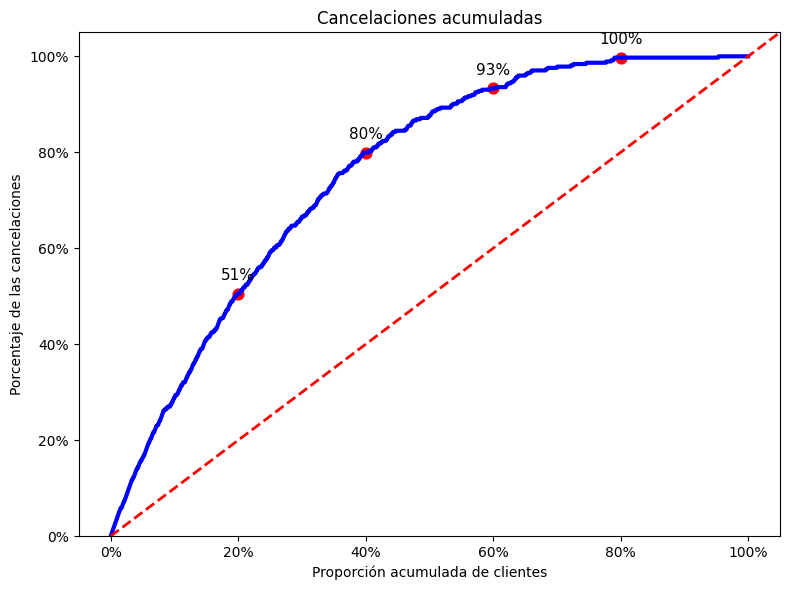

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ===============================
# DataFrame base
# ===============================

df = pd.DataFrame({
    "y_true": y_test,
    "y_prob": probs["Logit"]
})

df = df.sort_values("y_prob", ascending=False).reset_index(drop=True)

# ===============================
# Cálculo Lift
# ===============================

total_positives = df["y_true"].sum()

df["cum_positives"] = df["y_true"].cumsum()
df["cum_population"] = np.arange(1, len(df) + 1)

df["cum_positive_rate"] = df["cum_positives"] / total_positives
df["cum_population_rate"] = df["cum_population"] / len(df)

df["lift"] = df["cum_positive_rate"] / df["cum_population_rate"]

# ===============================
# Plot
# ===============================

fig, ax = plt.subplots(figsize=(8,6))

# Curva lift (más gruesa)
ax.plot(
    df["cum_population_rate"],
    df["cum_positive_rate"],
    color="blue",
    linewidth=3
)

# Línea base (azar)

ax.axline((0, 0), (1, 1), linewidth=2, color='red',  linestyle="--",
)
# Eje Y desde 0
ax.set_ylim(bottom=0)

# Eje X en porcentaje
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_xlabel("Proporción acumulada de clientes")
ax.set_ylabel("Lift")
ax.set_title("Cancelaciones acumuladas")

# ===============================
# Marcar puntos 20%, 40%, 60%, 80%
# ===============================

marks = [0.2, 0.4, 0.6, 0.8]

for m in marks:

    idx = (df["cum_population_rate"] - m).abs().idxmin()
    x = df.loc[idx, "cum_population_rate"]
    y = df.loc[idx, "cum_positive_rate"]

    ax.scatter(x, y, color="red", s=60)

    ax.annotate(
        f"{y*100:.0f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha="center",
        fontsize=11,
        color="black"
    )

plt.tight_layout()
plt.ylabel("Porcentaje de las cancelaciones")
plt.show()

# Simulación

Se realizaron 10,000 simulaciones utilizando el modelo logístico para estimar las probabilidades de cancelación. Para cada simulación se estimo la ganancia total tras 6 meses más la cantidad de clientes retenidos.

Si no se realizase ninguna intervención se obtiene una ganancia total promedio de $69,000 y se retienen un promedio de 12 clientes

Por otro lado, si se asigna un descuento del 50% sobre los gastos totales, se optienen tras 6 meses unas ganancias de $51,927 y se retienen 35 clientes.

*Nota: se utilizó la mediana como promedio para reducir la influencia de casos extremos*



In [116]:
import numpy as np
import pandas as pd






# ----------------------------
# 1. Combine dataset
# ----------------------------

data = pd.concat([X_train_scaled, X_test_scaled], axis=0).reset_index(drop=True)


# Keep original scale values
final_revenue = []
final_clientes = []
total_revenue=[]

n_months = 6
tenure_log_mean = 2.916736
tenure_log_sd = 1.327951
charges_monthly_log_mean = 4.023213
charges_monthly_log_sd = 0.593952
model_features = ['gender_male', 'senior_citizen_65', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'paperless_billing', 'charges_monthly_log', 'tenure_log',
       'subcription_no_streaming', 'dsl', 'fiber_optic', 'month_to_month',
       'one_year', 'two_year', 'bank_transfer_automatic',
       'credit_card_automatic', 'electronic_check', 'mailed_check']



for i in range(10_000):
# ----------------------------
# Predict probabilities
# ----------------------------
    data = pd.concat([X_train_scaled, X_test_scaled], axis=0).reset_index(drop=True)

    probs = best_logit.predict_proba(data)[:, 1]
    data["prob_churn"] = probs

# ----------------------------
# Keep top 20% highest risk
# ----------------------------
    cutoff = data["prob_churn"].quantile(0.80)
    data = data[data["prob_churn"] >= cutoff].copy()

##Original variables
    data["tenure_original"] = np.exp( data["tenure_log"] * tenure_log_sd + tenure_log_mean )
    data["charges_monthly_original"] =np.exp( data["charges_monthly_log"] *charges_monthly_log_sd + charges_monthly_log_mean )


    for month in range(n_months):

        # ----------------------------
        # 2. Transform tenure
        # ----------------------------


        data["tenure_log"] = np.log(data["tenure_original"] + month) / tenure_log_sd  - tenure_log_mean / tenure_log_sd


        # build model input
        X_sim = data[model_features]

        # ----------------------------
        # 3. Predict churn probability
        # ----------------------------

        probs = calibrate(X_sim)

        # ----------------------------
        # 4. Simulate churn
        # ----------------------------

        churn = np.random.binomial(1, probs)
        data["churn"] = churn

        # ----------------------------
        # 5. Compute revenue
        # ----------------------------

        monthly_revenue = (data["charges_monthly_original"]*(1-churn) * 1).sum()
        total_revenue.append(monthly_revenue)

        # ----------------------------
        # 6. Remove churned clients
        # ----------------------------
        data = data[data["churn"] == 0].copy()

    final_revenue.append( np.sum(total_revenue))
    final_clientes.append(data.shape[0])
    total_revenue=[]





print("Ganancias: ", np.median(final_revenue))
print("Clientes:", np.median( final_clientes) )


Ganancias:  68598.78524087518
Clientes: 11.8111


In [117]:
# ----------------------------
# 1. Combine dataset
# ----------------------------

data = pd.concat([X_train_scaled, X_test_scaled], axis=0).reset_index(drop=True)


# Keep original scale values
final_revenue = []
final_clientes = []
total_revenue = []
n_months = 6
tenure_log_mean = 2.916736
tenure_log_sd = 1.327951
charges_monthly_log_mean = 4.023213
charges_monthly_log_sd = 0.593952
model_features = ['gender_male', 'senior_citizen_65', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'paperless_billing', 'charges_monthly_log', 'tenure_log',
       'subcription_no_streaming', 'dsl', 'fiber_optic', 'month_to_month',
       'one_year', 'two_year', 'bank_transfer_automatic',
       'credit_card_automatic', 'electronic_check', 'mailed_check']



for i in range(10_000):
# ----------------------------
# Predict probabilities
# ----------------------------
    data = pd.concat([X_train_scaled, X_test_scaled], axis=0).reset_index(drop=True)

    probs = best_logit.predict_proba(data)[:, 1]
    data["prob_churn"] = probs

    # ----------------------------
    # Keep top 20% highest risk
    # ----------------------------
    cutoff = data["prob_churn"].quantile(0.80)
    data = data[data["prob_churn"] >= cutoff].copy()

    ##Original variables
    data["tenure_original"] = np.exp( data["tenure_log"] * tenure_log_sd + tenure_log_mean )
    data["charges_monthly_original"] =np.exp( data["charges_monthly_log"] *charges_monthly_log_sd + charges_monthly_log_mean )
    #Promocón 50%
    data["charges_monthly_original"] = data["charges_monthly_original"] *0.5
    data["charges_monthly_log"] = np.log(data["charges_monthly_original"] + month) / charges_monthly_log_sd  - charges_monthly_log_mean /charges_monthly_log_sd

    for month in range(n_months):

        # ----------------------------
        # 2. Transform tenure
        # ----------------------------

        data["tenure_log"] = np.log(data["tenure_original"] + month) / tenure_log_sd  - tenure_log_mean / tenure_log_sd

        # build model input
        X_sim = data[model_features]

        # ----------------------------
        # 3. Predict churn probability
        # ----------------------------

        probs = calibrate(X_sim)

        # ----------------------------
        # 4. Simulate churn
        # ----------------------------

        churn = np.random.binomial(1, probs)
        data["churn"] = churn

        # ----------------------------
        # 5. Compute revenue
        # ----------------------------

        monthly_revenue = (data["charges_monthly_original"]*(1-churn) * 1).sum()
        total_revenue.append(monthly_revenue)

        # ----------------------------
        # 6. Remove churned clients
        # ----------------------------

        data = data[data["churn"] == 0].copy()

    final_revenue.append( np.sum(total_revenue))
    final_clientes.append(data.shape[0])
    total_revenue = []






print("Ganancias: ", np.median(final_revenue))
print("Clientes:", np.median( final_clientes) )

Ganancias:  51927.46376178437
Clientes: 35.0


# Conclusiones

- Se construyó un modelo permite priorizar a los clientes según su riesgo de cancelación. El top 20% de mayor riesgo concentra el 50% de las cancelaciones.
- Los factores principales para la cancelación son la antigüedad del cliente, sus gastos mensuales, el tipo de internet (fibra óptica, dsl o sin internet) y la duración del contrato (mensual, anual, bianual).
- Se destacan los efectos del tipo de servicio de internet, aquellos con fibra óptica presentan un 50% más de riesgo que aquellos con dsl o sin internet; y del tipo de contrato, el plan mensual tiene dos veces más riesgo de cancelar que clientes de plan anual y casi cuatro veces más que clientes del plan bianual.
- Un descuento del 50% en los gastos mensuales durante 6 meses no produce mejoras en la ganancias y apenas reduce la cancelación .



#  Mejoras Futuras

Existen tres mejoras principales que se pueden hacer:
- La principal mejora que este modelo podría tener es añadir nuevas variables. Consiguiendo nueva información de los clientes o de grupos de clientes podría mejorar radicalmente los modelos.
- Se realizó un supuesto muy fuerte durante el proceso de modelado y limpieza: los datos corresponden a un único momento del tiempo, un único mes. Si los datos representaran varios meses de observaciones entonces un modelo de supervivencia podría ser más apropiado.
- Incluir más observaciones. A medida que pasan los meses y diversos clientes cancelan (o no cancelan) estos pueden sumar volumen a los datos permitiendo mejorar las estmaciones.

Por otro lado, los modelos actuales se encuentran muy cerca del tope establecido, es decir aprovechan casi al máximo la información disponible. Sin embargo existe la posibilidad de mejorarlos levemente:

- Extender la selección de modelos. Notablemente variantes paramétricas como los modelos Probit, Cloglog o Regresión Lineal.
- Incluir ensambles de modelos, es decir un metamodelo que combine los resultados de varios modelos.
- Métodos de reducción de dimensión (ej: componentes principales).
- Incluir interacciones al modelo logístico.
- Incluir efectos cuadráticos al modelo logístico (los splines no mejoraron el modelo pero no se probaron efectos cuadráticos de forma explicita).
- Aplicar una selección de variables más rigurosa (eliminando variables correlacionadas entre ellas o con poca correlación con la cancelación).


